# P5a · LISA Spatial Outlier Analysis
## *RURIMESCAPE — Paper 1, Step 5a (supplementary block)*

---

**Paper:** Rural Migration and Land Use in Spain — Paper 1  
**Step:** 5a supplementary — Socioeconomic characterisation of LISA spatial outlier quadrants  
**Author:** Juan Zotes  
**Last updated:** 2026-04

---

### Context and purpose

This notebook extends the socioeconomic characterisation of Step 5a by focusing
on the **spatial structure of demographic behaviour**, as captured by the LISA
(Local Moran's I) quadrants computed in Step 4.

LISA was computed on `var_acum_pct_B` (cumulative population change, Period B
2018–2025) across all ~8,100 Spanish municipalities using a Queen spatial weights
matrix (p4, 9,999 permutations, p < 0.05). The four significant quadrants are:

| Quadrant | Municipality | Neighbours | Interpretation |
|----------|-------------|------------|----------------|
| **HH** | High growth | High growth | Demographic cluster — growth surrounded by growth |
| **HL** | High growth | Low growth  | Positive spatial outlier — isolated growth in declining context |
| **LH** | Low growth  | High growth | Negative spatial outlier — lagging municipality in dynamic context |
| **LL** | Low growth  | Low growth  | Demographic cold spot — decline surrounded by decline |

**Core analytical question:** What structural socioeconomic conditions differentiate
municipalities that grow in isolation (HL) from those that decline in a surrounding
of decline (LL)? And what differentiates lagging municipalities (LH) from those
forming part of growth clusters (HH)?

The **HL vs. LL comparison** is the most analytically powerful: both groups exist
in contexts of low neighbourhood growth (negative spatial lag), but one manages
to grow while the other does not — implicitly controlling for the regional
territorial context.

---

### Design decision: no behavioural group filter

This analysis operates on **all rural municipalities with a significant LISA
quadrant assignment**, regardless of their behavioural group (reverter, dynamiser,
structural decline, loses in B). The LISA quadrant is the sole grouping variable.

Filtering by behavioural group first would deplete the LL category — the vast
majority of LL municipalities are in structural decline, not reverters — making
the HL vs. LL comparison statistically meaningless. The behavioural group ×
LISA quadrant cross-tabulation is reported in §1 as descriptive context only.

---

### Stratification

Three strata produced for all analyses and figures — selection for paper deferred:
- **Rural-Remote** only
- **Rural-Accessible** only  
- **Rural-Combined** (Remote + Accessible)

---

### Analytical structure

| Section | Content |
|---------|--------|
| 0 | Environment, paths, constants |
| 1 | Data loading and LISA quadrant audit |
| 2 | Descriptive statistics by LISA quadrant × stratum |
| 3 | Statistical tests — KW + Dunn by LISA quadrant |
| 4 | Figures — boxplots by LISA quadrant |
| 5 | Export outputs |
| 6 | Interpretation notes |

---

### Inputs / Outputs

| File | Direction | Description |
|------|-----------|-------------|
| `p5a_rural_analysis_dataset.csv` | IN | Rural subset with SIDAMUN vars + `lisa_sig_quad` |
| `p5a_selected_variables.csv` | IN | Variable selection log — same 26 vars as p5a |
| `p5a_lisa_descriptive_stats.csv` | OUT | Medians by quadrant × stratum |
| `p5a_lisa_kw_results.csv` | OUT | KW results per variable × stratum |
| `p5a_lisa_dunn_results.csv` | OUT | Dunn post-hoc (Bonferroni-corrected) |
| `figures/p5a_lisa/` | OUT | Boxplot figures, two sets (Remote/Accessible + Combined) |

---
## 0 · Environment, paths, constants

In [1]:
"""
Notebook  : p5a_lisa_spatial_outliers.ipynb
Author    : Juan Zotes
Created   : 2026-04

Purpose:
    Socioeconomic characterisation of LISA spatial outlier quadrants
    (HH, HL, LH, LL) for all rural municipalities with a significant
    LISA assignment. No behavioural group filter — LISA quadrant is
    the sole grouping variable.

    Core comparisons: HL vs. LL  |  LH vs. HH
    Three strata: Rural-Remote, Rural-Accessible, Rural-Combined.
    Methods: KW + Dunn/Bonferroni, consistent with p5a.

Inputs:
    - p5a_rural_analysis_dataset.csv     (demography/derived/paper1)
    - p5a_selected_variables.csv         (demography/derived/paper1)

Outputs:
    - p5a_lisa_descriptive_stats.csv     (demography/derived/paper1)
    - p5a_lisa_kw_results.csv            (demography/derived/paper1)
    - p5a_lisa_dunn_results.csv          (demography/derived/paper1)
    - figures/p5a_lisa/
"""

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from scipy import stats
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Project root ──────────────────────────────────────────────────────────────
ROOT = Path(r'C:\Users\juanz\OneDrive\Desktop\UCM\RURIM ESCAPE\GeoSpatial\01_Python Data Analysis\rural-migration-land-use-spain')

DEMO_DERIV = ROOT / 'data/demography/derived/paper1'
INPUT_DATA   = DEMO_DERIV / 'p5a_rural_analysis_dataset.csv'
INPUT_SELVAR = DEMO_DERIV / 'p5a_selected_variables.csv'

FIG_DIR = ROOT / 'figures/p5a_lisa_spatial_outliers'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Typology constants ────────────────────────────────────────────────────────
RURAL_REMOTE     = 'Rural - Remoto'
RURAL_ACCESSIBLE = 'Rural - Accesible'

# ── LISA quadrant colours and descriptions ────────────────────────────────────
QUAD_ORDER = ['HH', 'HL', 'LH', 'LL']
QUAD_COLORS = {
    'HH': '#d7191c',
    'HL': '#fdae61',
    'LH': '#abd9e9',
    'LL': '#2c7bb6',
}
QUAD_DESCRIPTIONS = {
    'HH': 'Growth cluster',
    'HL': 'Positive outlier',
    'LH': 'Negative outlier',
    'LL': 'Cold spot',
}

# ── Analysis strata: label → typology filter value (None = no filter) ─────────
STRATA = {
    'Rural-Remote':     RURAL_REMOTE,
    'Rural-Accessible': RURAL_ACCESSIBLE,
    'Rural-Combined':   None,
}

FONTSIZE = 12

for p in [INPUT_DATA, INPUT_SELVAR]:
    print(f'  {"✓" if p.exists() else "✗  NOT FOUND"}  {p.name}')

  ✓  p5a_rural_analysis_dataset.csv
  ✓  p5a_selected_variables.csv


---
## 1 · Data loading and LISA quadrant audit

In [3]:
# ── 1.1 Load ──────────────────────────────────────────────────────────────────
df = pd.read_csv(INPUT_DATA, sep=';', encoding='utf-8-sig', dtype={'Mun_Code': str})
df['Mun_Code'] = df['Mun_Code'].str.zfill(5)

df_selvar = pd.read_csv(INPUT_SELVAR, sep=';', encoding='utf-8-sig')
SELECTED_VARS = df_selvar[df_selvar['selected'] == True]['variable'].tolist()

# Significant LISA municipalities only — these are the analysis units
df_sig = df[df['lisa_sig_quad'].isin(QUAD_ORDER)].copy()

print(f'All rural municipalities:         {len(df):>6,}')
print(f'Significant LISA (HH+HL+LH+LL):  {len(df_sig):>6,}')
print(f'Not significant (ns):             {(df["lisa_sig_quad"] == "ns").sum():>6,}')
print(f'Missing lisa_sig_quad:            {df["lisa_sig_quad"].isna().sum():>6,}')
print(f'Selected SIDAMUN variables:       {len(SELECTED_VARS):>6}')

All rural municipalities:          6,717
Significant LISA (HH+HL+LH+LL):   1,939
Not significant (ns):              4,778
Missing lisa_sig_quad:                 0
Selected SIDAMUN variables:           44


In [4]:
# ── 1.2 Quadrant × typology distribution ─────────────────────────────────────
print('LISA quadrant distribution by typology (significant only):')
ct = pd.crosstab(df_sig['lisa_sig_quad'], df_sig['tipo_goerlich'], margins=True)
print(ct.reindex([q for q in QUAD_ORDER if q in ct.index] + ['All']).to_string())
print()

for typ in [RURAL_REMOTE, RURAL_ACCESSIBLE]:
    sub = df_sig[df_sig['tipo_goerlich'] == typ]
    typ_short = 'Remote' if typ == RURAL_REMOTE else 'Accessible'
    print(f'{typ_short} (n_sig={len(sub):,}):')
    for q in QUAD_ORDER:
        n = (sub['lisa_sig_quad'] == q).sum()
        pct = n / len(sub) * 100 if len(sub) > 0 else 0
        print(f'  {q} {QUAD_DESCRIPTIONS[q]:<20}: {n:>5,}  ({pct:.1f}%)')
    print()

LISA quadrant distribution by typology (significant only):
tipo_goerlich  Rural - Accesible  Rural - Remoto   All
lisa_sig_quad                                         
HH                           446             102   548
HL                            74             109   183
LH                            73              55   128
LL                           468             612  1080
All                         1061             878  1939

Remote (n_sig=878):
  HH Growth cluster      :   102  (11.6%)
  HL Positive outlier    :   109  (12.4%)
  LH Negative outlier    :    55  (6.3%)
  LL Cold spot           :   612  (69.7%)

Accessible (n_sig=1,061):
  HH Growth cluster      :   446  (42.0%)
  HL Positive outlier    :    74  (7.0%)
  LH Negative outlier    :    73  (6.9%)
  LL Cold spot           :   468  (44.1%)



In [5]:
# ── 1.3 Cross-tab: LISA quadrant × behavioural group (context only) ───────────
# Shows why filtering by behavioural group first would deplete LL:
# most LL municipalities are structural decline, not reverters.

df_sig_bg = df_sig[df_sig['behavioural_group'].notna()].copy()

for typ, typ_short in [(RURAL_REMOTE, 'Rural-Remote'), (RURAL_ACCESSIBLE, 'Rural-Accessible')]:
    sub = df_sig_bg[df_sig_bg['tipo_goerlich'] == typ]
    print(f'Quadrant × behavioural group — {typ_short} (context only, not a filter):')
    ct = pd.crosstab(sub['lisa_sig_quad'], sub['behavioural_group'], margins=True)
    print(ct.reindex([q for q in QUAD_ORDER if q in ct.index] + ['All']).to_string())
    print()

Quadrant × behavioural group — Rural-Remote (context only, not a filter):
behavioural_group  Grows in both  Loses in B  Reverses in B  Structural depopulation  All
lisa_sig_quad                                                                            
HH                            22           0             80                        0  102
HL                             7           0            102                        0  109
LH                             0           5              6                       44   55
LL                             0          40             10                      562  612
All                           29          45            198                      606  878

Quadrant × behavioural group — Rural-Accessible (context only, not a filter):
behavioural_group  Grows in both  Loses in B  Reverses in B  Structural depopulation   All
lisa_sig_quad                                                                             
HH                           189   

---
## 2 · Descriptive statistics by LISA quadrant × stratum

In [6]:
# ── 2.1 Medians per quadrant × stratum ───────────────────────────────────────

desc_rows = []
for stratum_name, typology_val in STRATA.items():
    df_s = df_sig if typology_val is None else df_sig[df_sig['tipo_goerlich'] == typology_val]
    for quad in QUAD_ORDER:
        df_q = df_s[df_s['lisa_sig_quad'] == quad]
        if len(df_q) == 0:
            continue
        row = {'stratum': stratum_name, 'lisa_quad': quad,
               'quad_description': QUAD_DESCRIPTIONS[quad], 'n': len(df_q)}
        for var in SELECTED_VARS:
            if var in df_q.columns:
                row[var + '__median']  = df_q[var].median()
                row[var + '__n_valid'] = df_q[var].notna().sum()
        desc_rows.append(row)

df_desc = pd.DataFrame(desc_rows)

# Quick n summary
pivot = df_desc.pivot_table(index='lisa_quad', columns='stratum', values='n', aggfunc='first')
print('N municipalities per quadrant × stratum:')
print(pivot.reindex(QUAD_ORDER).to_string())

N municipalities per quadrant × stratum:
stratum    Rural-Accessible  Rural-Combined  Rural-Remote
lisa_quad                                                
HH                      446             548           102
HL                       74             183           109
LH                       73             128            55
LL                      468            1080           612


In [7]:
# ── 2.2 Key variable preview: HL vs. LL medians ───────────────────────────────

key_vars = [
    'VIVIENDA__HOGAR__Tamaño medio del hogar',
    'ECONOMIA__RENTAS__Renta neta media por hogar',
    'ECONOMIA__RENTAS__DESIGUALDAD__Índice de Gini (%)',
    'SERVICIOS__DISTANCIAS A LOS SERVICIOS MÁS CERCANOS__Tiempo municipio 5.000 hab. o más, más cercano (minutos)',
    'MEDIO FÍSICO__Densidad (hab/km2)',
]

for stratum_name in STRATA:
    sub = df_desc[df_desc['stratum'] == stratum_name]
    vals = {row['lisa_quad']: row for _, row in sub.iterrows()}
    print(f'\n--- {stratum_name} ---')
    print(f'{"Variable":<55} {"HH":>10} {"HL":>10} {"LH":>10} {"LL":>10}')
    print('-' * 92)
    for var in key_vars:
        col = var + '__median'
        label = ' '.join(var.split('__')[-1].split())[:53]
        def fmt(q):
            v = vals.get(q, {}).get(col, np.nan)
            return f'{v:.1f}' if v is not None and not np.isnan(v) else '—'
        print(f'{label:<55} {fmt("HH"):>10} {fmt("HL"):>10} {fmt("LH"):>10} {fmt("LL"):>10}')


--- Rural-Remote ---
Variable                                                        HH         HL         LH         LL
--------------------------------------------------------------------------------------------
Tamaño medio del hogar                                         2.3        2.2        2.0        2.0
Renta neta media por hogar                                 29554.0    26450.0    29288.5    25932.0
Índice de Gini (%)                                            29.9       28.4       28.1       28.0
Tiempo municipio 5.000 hab. o más, más cercano (minut         28.2       34.1       33.3       36.5
Densidad (hab/km2)                                             8.5        3.3        2.8        4.0

--- Rural-Accessible ---
Variable                                                        HH         HL         LH         LL
--------------------------------------------------------------------------------------------
Tamaño medio del hogar                                         2.6

---
## 3 · Statistical tests — KW + Dunn by LISA quadrant

In [8]:
# ── 3.1 Dunn post-hoc helper (identical to p5a) ───────────────────────────────

def dunn_bonferroni(data_dict):
    group_names  = list(data_dict.keys())
    pairs        = list(combinations(group_names, 2))
    n_comparisons = len(pairs)
    results = []
    for g1, g2 in pairs:
        arr1, arr2 = data_dict[g1], data_dict[g2]
        if len(arr1) < 2 or len(arr2) < 2:
            results.append({'group1': g1, 'group2': g2,
                            'p_raw': np.nan, 'p_bonf': np.nan, 'significant': False})
            continue
        _, p_raw = stats.mannwhitneyu(arr1, arr2, alternative='two-sided')
        p_bonf   = min(p_raw * n_comparisons, 1.0)
        results.append({'group1': g1, 'group2': g2,
                        'p_raw': round(p_raw, 6), 'p_bonf': round(p_bonf, 6),
                        'significant': p_bonf < 0.05})
    return pd.DataFrame(results)

print('Dunn helper defined.')

Dunn helper defined.


In [9]:
# ── 3.2 KW + Dunn per variable × stratum ─────────────────────────────────────

kw_rows   = []
dunn_rows = []

for stratum_name, typology_val in STRATA.items():
    df_s = df_sig if typology_val is None else df_sig[df_sig['tipo_goerlich'] == typology_val]
    quads_present = [q for q in QUAD_ORDER
                     if len(df_s[df_s['lisa_sig_quad'] == q]) >= 5]
    if len(quads_present) < 2:
        continue

    for var in SELECTED_VARS:
        if var not in df_s.columns:
            continue
        groups_data = [
            df_s[df_s['lisa_sig_quad'] == q][var].dropna().values
            for q in quads_present
        ]
        groups_valid = [g for g in groups_data if len(g) >= 2]
        if len(groups_valid) < 2:
            continue
        try:
            stat, p_val = stats.kruskal(*groups_valid)
            significant = p_val < 0.05
            kw_rows.append({
                'stratum': stratum_name, 'variable': var,
                'variable_short': ' '.join(var.split('__')[-1].split()),
                'kw_stat': round(stat, 4), 'kw_p': round(p_val, 6),
                'significant': significant,
                'quads_tested': ', '.join(quads_present),
            })
            if significant:
                data_dict = {
                    q: df_s[df_s['lisa_sig_quad'] == q][var].dropna().values
                    for q in quads_present
                }
                df_dunn = dunn_bonferroni(data_dict)
                df_dunn['stratum']        = stratum_name
                df_dunn['variable']       = var
                df_dunn['variable_short'] = ' '.join(var.split('__')[-1].split())
                dunn_rows.append(df_dunn)
        except Exception:
            continue

df_kw       = pd.DataFrame(kw_rows)
df_dunn_all = pd.concat(dunn_rows, ignore_index=True) if dunn_rows else pd.DataFrame()

print(f'KW tests run:                       {len(df_kw):>5}')
print(f'Significant (p < 0.05):             {df_kw["significant"].sum() if len(df_kw) > 0 else 0:>5}')
print(f'Dunn pairwise comparisons:          {len(df_dunn_all):>5}')
if len(df_dunn_all) > 0:
    print(f'Significant (Bonf. p < 0.05):       {df_dunn_all["significant"].sum():>5}')
print()
if len(df_kw) > 0:
    print('Significant KW by stratum:')
    print(df_kw.groupby('stratum').agg(
        total=('variable','count'), significant=('significant','sum')
    ).to_string())

KW tests run:                         132
Significant (p < 0.05):               122
Dunn pairwise comparisons:            732
Significant (Bonf. p < 0.05):         437

Significant KW by stratum:
                  total  significant
stratum                             
Rural-Accessible     44           44
Rural-Combined       44           42
Rural-Remote         44           36


In [10]:
# ── 3.3 Primary comparison summary: HL vs. LL and LH vs. HH ──────────────────

if len(df_dunn_all) > 0:
    for g1, g2 in [('HL', 'LL'), ('LH', 'HH')]:
        mask = (
            ((df_dunn_all['group1'] == g1) & (df_dunn_all['group2'] == g2)) |
            ((df_dunn_all['group1'] == g2) & (df_dunn_all['group2'] == g1))
        ) & df_dunn_all['significant']
        df_pair = df_dunn_all[mask].copy()
        print(f'\n{g1} vs. {g2} — significant Dunn pairs (Bonferroni p < 0.05): {len(df_pair)}')
        if len(df_pair) > 0:
            print(df_pair[['stratum', 'variable_short', 'p_bonf']]
                  .sort_values(['stratum', 'p_bonf'])
                  .to_string(index=False))


HL vs. LL — significant Dunn pairs (Bonferroni p < 0.05): 50
         stratum                                      variable_short   p_bonf
Rural-Accessible                                         Pct_65_plus 0.000000
Rural-Accessible                                 Pct_Mujeres_65_plus 0.000000
Rural-Accessible                                Edad media población 0.000000
Rural-Accessible Población Nacionalidad Extranjera (% hab. s/ total) 0.000008
Rural-Accessible                                    Pct_Mujeres_0_14 0.000018
Rural-Accessible                           Índice envejecimiento (%) 0.000021
Rural-Accessible                              Tamaño medio del hogar 0.000032
Rural-Accessible                                            Pct_0_14 0.000071
Rural-Accessible                                           Pct_15_29 0.000103
Rural-Accessible                                   Pct_Mujeres_15_29 0.000170
Rural-Accessible                                Tasa dependencia (%) 0.000412
Ru

---
## 4 · Figures — boxplots by LISA quadrant

Two figure sets:
- **Set A:** Remote (left) | Accessible (right) — same layout as p5a main figures
- **Set B:** Combined — single column

Five thematic blocks per set (same as p5a). X-axis: LISA quadrants with n
per quadrant shown in tick labels. Dunn annotations: HL–LL and LH–HH only.

In [11]:
# ── 4.1 Labels, variable groups, helpers ──────────────────────────────────────

VAR_LABELS_EN = {
    'Renta neta media por persona':                                        'Net income per capita (€)',
    'Renta neta media por hogar':                                          'Net household income (€)',
    'Índice de Gini (%)':                                                  'Gini index (%)',
    'Distribución de la renta P80/P20':                                    'Income ratio P80/P20',
    'Tasa de paro':                                                        'Unemployment rate (%)',
    'Afiliados Régimen Especial (R. E.) T. Autónomos (% s/ Total)':       'Self-employed affiliates (%)',
    'Contratos indefinidos (% s/ Total)':                                  'Permanent contracts (%)',
    'Total Empresas':                                                      'Total firms',
    'Pensión Contributiva Media':                                          'Mean contributory pension (€)',
    'Porcentaje cobertura ≥ 100 Mbps (condiciones máxima demanda)':       'Broadband ≥100 Mbps (%)',
    'Consultorio de atención primaria (número)':                           'Primary care centres (n)',
    'Oficina de farmacia (número)':                                        'Pharmacies (n)',
    'Nº centros de Educación Primaria':                                    'Primary schools (n)',
    'Tiempo municipio 5.000 hab. o más, más cercano (minutos)':           'Time to 5,000-hab. town (min)',
    'Tiempo municipio 20.000 hab. o más, más cercano (minutos)':          'Time to 20,000-hab. town (min)',
    'Sucursal bancaria (número)':                                          'Bank branches (n)',
    'Parque de vehículos x c/ 100 hab.':                                  'Vehicles per 100 inhab.',
    'Viviendas no principales (% s/ total)':                              'Non-primary dwellings (%)',
    'Tamaño medio del hogar':                                             'Mean household size',
    'Hogares unipersonales (% s/ total)':                                 'Single-person households (%)',
    'Plazas turísticas x c/ 100 hab.':                                    'Tourist beds per 100 inhab.',
    'Altitud capital (m)':                                                 'Elevation (m)',
    'Densidad (hab/km2)':                                                  'Population density (hab/km²)',
    'Superficie (km2)':                                                    'Municipal area (km²)',
    'Superficie forestal (% s/ total)':                                    'Forest cover (%)',
    'Superficie protegida (% s/ total)':                                   'Protected area (%)',
    # ── Demographic (new) ─────────────────────────────────────────────────────
    'Mujeres \n(% hab. s/ total)':                                          'Women (% total population)',
    'Pct_0_14':                                                             'Children 0–14 years (%)',
    'Pct_15_29':                                                            'Youth 15–29 years (%)',
    'Pct_30_64':                                                            'Adults 30–64 years (%)',
    'Pct_65_plus':                                                          'Seniors ≥65 years (%)',
    'Pct_Mujeres_0_14':                                                     'Women 0–14 years (%)',
    'Pct_Hombres_0_14':                                                     'Men 0–14 years (%)',
    'Pct_Mujeres_15_29':                                                    'Women 15–29 years (%)',
    'Pct_Hombres_15_29':                                                    'Men 15–29 years (%)',
    'Pct_Mujeres_30_64':                                                    'Women 30–64 years (%)',
    'Pct_Hombres_30_64':                                                    'Men 30–64 years (%)',
    'Pct_Mujeres_65_plus':                                                  'Women ≥65 years (%)',
    'Pct_Hombres_65_plus':                                                  'Men ≥65 years (%)',
    'Edad media población':                                                 'Mean age (years)',
    'Índice envejecimiento\n(%)':                                           'Aging index (%)',
    'Tasa dependencia \n(%)':                                               'Dependency ratio (%)',
    'Población Nacionalidad Extranjera \n(% hab. s/ total)':                 'Foreign nationals (% total population)',
}

def get_label(var_full):
    short = ' '.join(var_full.split('__')[-1].split())
    return next((v for k, v in VAR_LABELS_EN.items() if ' '.join(k.split()) == short), short)

PROPORTION_VARS = {
    'SERVICIOS__INTERNET__Porcentaje cobertura ≥ 100 Mbps (condiciones máxima demanda)': 100,
}

FIGURE_GROUPS = [
    {'label': 'economic_income', 'suptitle': 'Economic conditions — Income and inequality',
     'vars': ['ECONOMIA__RENTAS__Renta neta media por hogar',
              'ECONOMIA__RENTAS__DESIGUALDAD__Índice de Gini (%)',
              'ECONOMIA__RENTAS__DESIGUALDAD__Distribución de la renta P80/P20']},
    {'label': 'economic_labour', 'suptitle': 'Economic conditions — Labour market and enterprise',
     'vars': ['ECONOMIA__PARADOS__POR SEXO__Tasa de paro',
              'ECONOMIA__CONTRATOS__POR DURACIÓN__Contratos indefinidos \n(% s/ Total)',
              'ECONOMIA__AFILIADOS__POR SECTOR__Afiliados Régimen Especial (R. E.) T. Autónomos \n(% s/ Total)',
              'ECONOMIA__PENSIONES CONTRIBUTIVAS__Pensión Contributiva Media']},
    {'label': 'services', 'suptitle': 'Service provision and accessibility',
     'vars': ['SERVICIOS__DISTANCIAS A LOS SERVICIOS MÁS CERCANOS__Tiempo municipio 5.000 hab. o más, más cercano (minutos)',
              'SERVICIOS__DISTANCIAS A LOS SERVICIOS MÁS CERCANOS__Tiempo municipio 20.000 hab. o más, más cercano (minutos)',
              'SERVICIOS__INTERNET__Porcentaje cobertura ≥ 100 Mbps (condiciones máxima demanda)']},
    {'label': 'housing', 'suptitle': 'Housing characteristics',
     'vars': ['VIVIENDA__HOGAR__Tamaño medio del hogar',
              'VIVIENDA__TIPOS DE VIVIENDAS (familiares)__Viviendas no principales (% s/ total)',
              'VIVIENDA__HOGAR__Hogares unipersonales \n(% s/ total)',
              'VIVIENDA__VIVIENDAS TURÍSTICAS__Plazas turísticas x c/ 100 hab.']},
    {'label': 'physical_environment', 'suptitle': 'Physical environment and natural capital',
     'vars': ['MEDIO FÍSICO__Densidad (hab/km2)',
              'MEDIO FÍSICO__Altitud capital \n(m)',
              'MEDIOAMBIENTE__CAPITAL NATURAL__FORESTAL__Superficie forestal \n(% s/ total)',
              'MEDIOAMBIENTE__CAPITAL NATURAL__ESPACIOS PROTEGIDOS__Superficie protegida \n(% s/ total)']},
    {'label': 'demographic', 'suptitle': 'Demographic structure',
     'vars': ['DEMOGRAFIA__POBLACIÓN POR SEXO__Mujeres \n(% hab. s/ total)',
              'DEMOGRAFIA__Pct_0_14',
              'DEMOGRAFIA__Pct_15_29',
              'DEMOGRAFIA__Pct_30_64',
              'DEMOGRAFIA__Pct_65_plus',
              'DEMOGRAFIA__Pct_Mujeres_0_14',
              'DEMOGRAFIA__Pct_Hombres_0_14',
              'DEMOGRAFIA__Pct_Mujeres_15_29',
              'DEMOGRAFIA__Pct_Hombres_15_29',
              'DEMOGRAFIA__Pct_Mujeres_30_64',
              'DEMOGRAFIA__Pct_Hombres_30_64',
              'DEMOGRAFIA__Pct_Mujeres_65_plus',
              'DEMOGRAFIA__Pct_Hombres_65_plus',
              'DEMOGRAFIA__EDAD MEDIA__Edad media población',
              'DEMOGRAFIA__RATIOS__Índice envejecimiento\n(%)',
              'DEMOGRAFIA__RATIOS__Tasa dependencia \n(%)',
              'DEMOGRAFIA__NACIONALIDAD__Población Nacionalidad Extranjera \n(% hab. s/ total)',
     ]},
]

def add_lisa_annotation(ax, stratum, var, quads_present):
    """Annotate HL–LL and LH–HH Dunn significance on a panel."""
    if len(df_dunn_all) == 0:
        return
    df_local = df_dunn_all[
        (df_dunn_all['stratum'] == stratum) & (df_dunn_all['variable'] == var)
    ]
    lines = []
    for g1, g2 in [('HL', 'LL'), ('LH', 'HH')]:
        if g1 not in quads_present or g2 not in quads_present:
            continue
        mask = (
            ((df_local['group1'] == g1) & (df_local['group2'] == g2)) |
            ((df_local['group1'] == g2) & (df_local['group2'] == g1))
        )
        row = df_local[mask]
        if len(row) == 0 or np.isnan(row['p_bonf'].values[0]):
            continue
        p = row['p_bonf'].values[0]
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        lines.append(f'{g1}–{g2}: {stars}')
    if lines:
        ax.text(0.97, 0.97, '\n'.join(lines), transform=ax.transAxes,
                ha='right', va='top', fontsize=FONTSIZE - 2,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.75))

print('Helpers defined.')

Helpers defined.


In [12]:
# ── HL vs. LL direct comparison table — all variables, all strata ─────────────

print('HL vs. LL — median comparison for all selected variables\n')

sep1 = '=' * 85
sep2 = '-' * 85

for stratum_name, typology_val in STRATA.items():
    df_s  = df_sig if typology_val is None else df_sig[df_sig['tipo_goerlich'] == typology_val]
    df_hl = df_s[df_s['lisa_sig_quad'] == 'HL']
    df_ll = df_s[df_s['lisa_sig_quad'] == 'LL']

    print(sep1)
    print(f'{stratum_name}  |  HL n={len(df_hl):,}  |  LL n={len(df_ll):,}')
    print(sep1)
    print(f'{"Variable":<58} {"HL median":>12} {"LL median":>12} {"Dunn sig":>10}')
    print(sep2)

    for var in SELECTED_VARS:
        if var not in df_s.columns:
            continue
        med_hl = df_hl[var].median()
        med_ll = df_ll[var].median()
        label  = get_label(var)[:56]

        sig_str = ''
        if len(df_dunn_all) > 0:
            mask = (
                (df_dunn_all['stratum'] == stratum_name) &
                (df_dunn_all['variable'] == var) &
                (
                    ((df_dunn_all['group1'] == 'HL') & (df_dunn_all['group2'] == 'LL')) |
                    ((df_dunn_all['group1'] == 'LL') & (df_dunn_all['group2'] == 'HL'))
                )
            )
            row = df_dunn_all[mask]
            if len(row) > 0:
                p = row['p_bonf'].values[0]
                if not np.isnan(p):
                    sig_str = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

        hl_str = f'{med_hl:.2f}' if not np.isnan(med_hl) else '—'
        ll_str = f'{med_ll:.2f}' if not np.isnan(med_ll) else '—'
        print(f'{label:<58} {hl_str:>12} {ll_str:>12} {sig_str:>10}')
    print()

HL vs. LL — median comparison for all selected variables

Rural-Remote  |  HL n=109  |  LL n=612
Variable                                                      HL median    LL median   Dunn sig
-------------------------------------------------------------------------------------
Women (% total population)                                        44.29        45.71          *
Children 0–14 years (%)                                            5.41         4.53         ns
Youth 15–29 years (%)                                             10.42         8.70         **
Adults 30–64 years (%)                                            48.12        45.48        ***
Seniors ≥65 years (%)                                             30.00        35.70        ***
Women 0–14 years (%)                                               2.56         2.08         ns
Men 0–14 years (%)                                                 2.67         2.29         ns
Women 15–29 years (%)                            

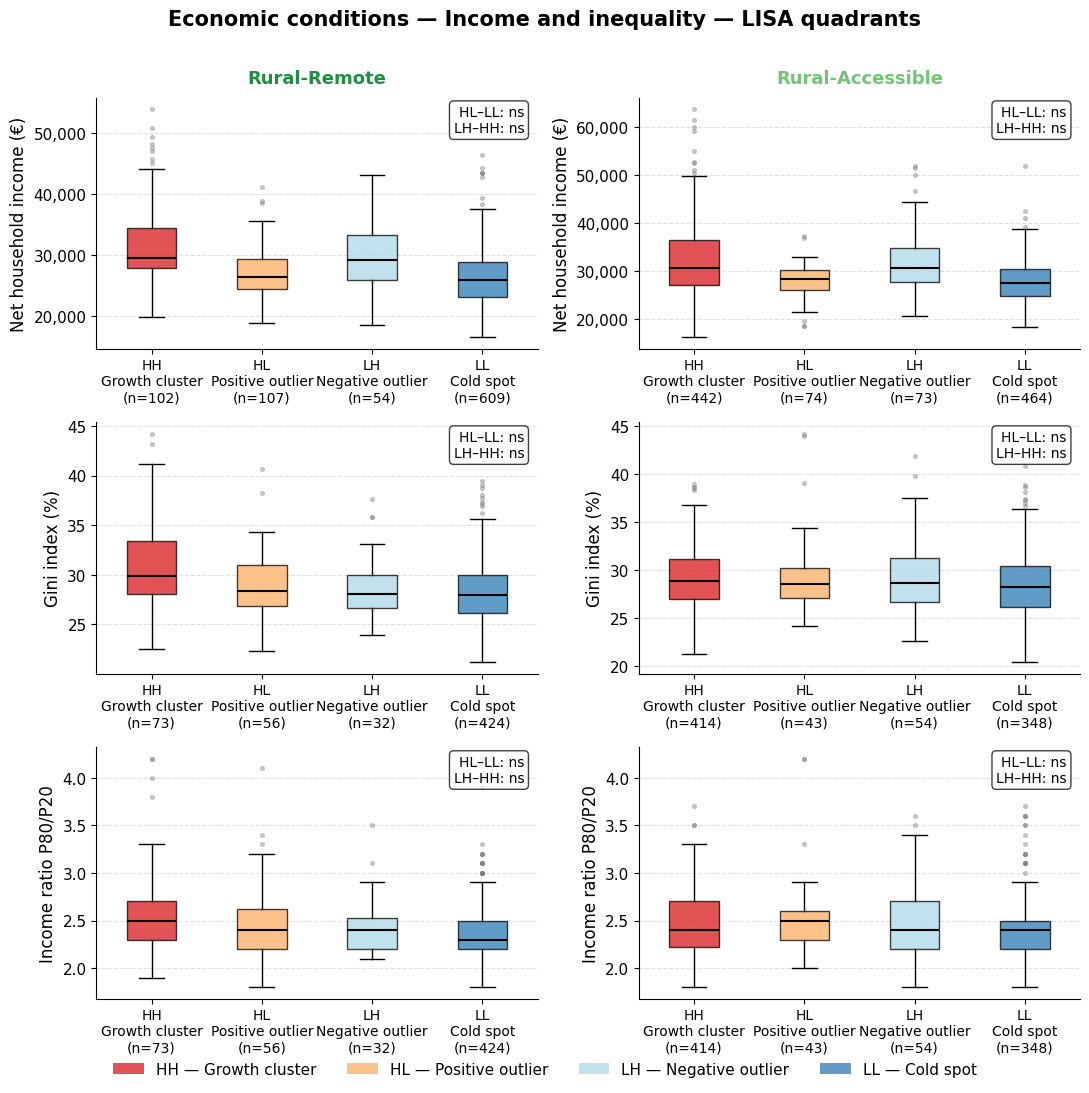

  ✓  p5a_lisa_remote_vs_accessible_economic_income.png


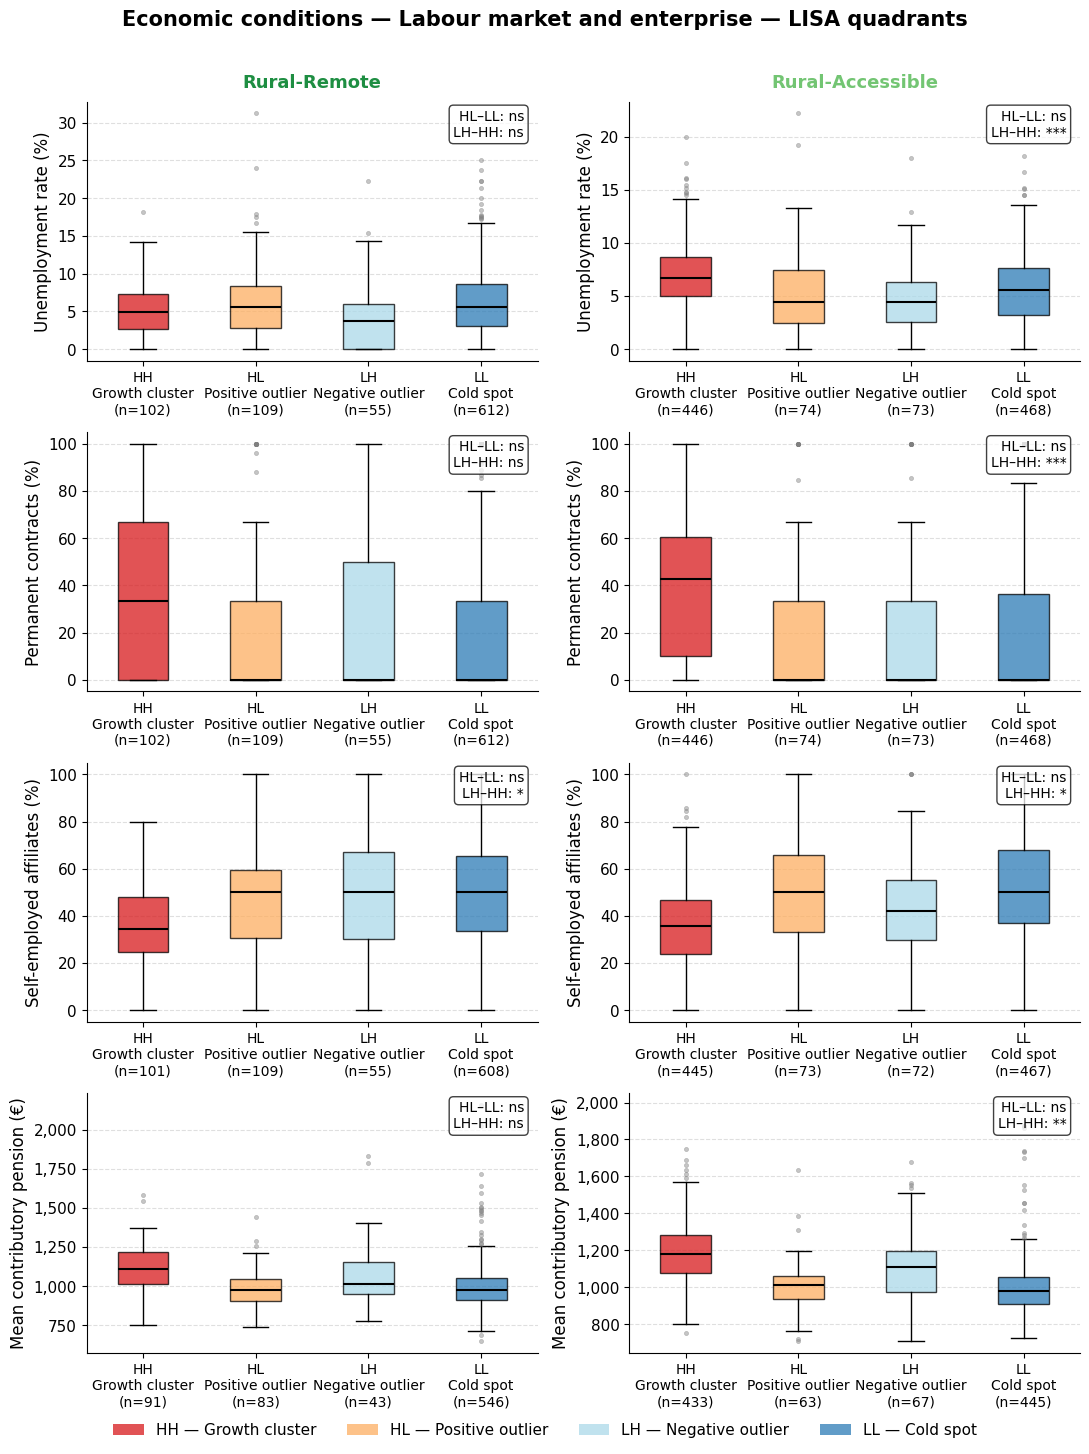

  ✓  p5a_lisa_remote_vs_accessible_economic_labour.png


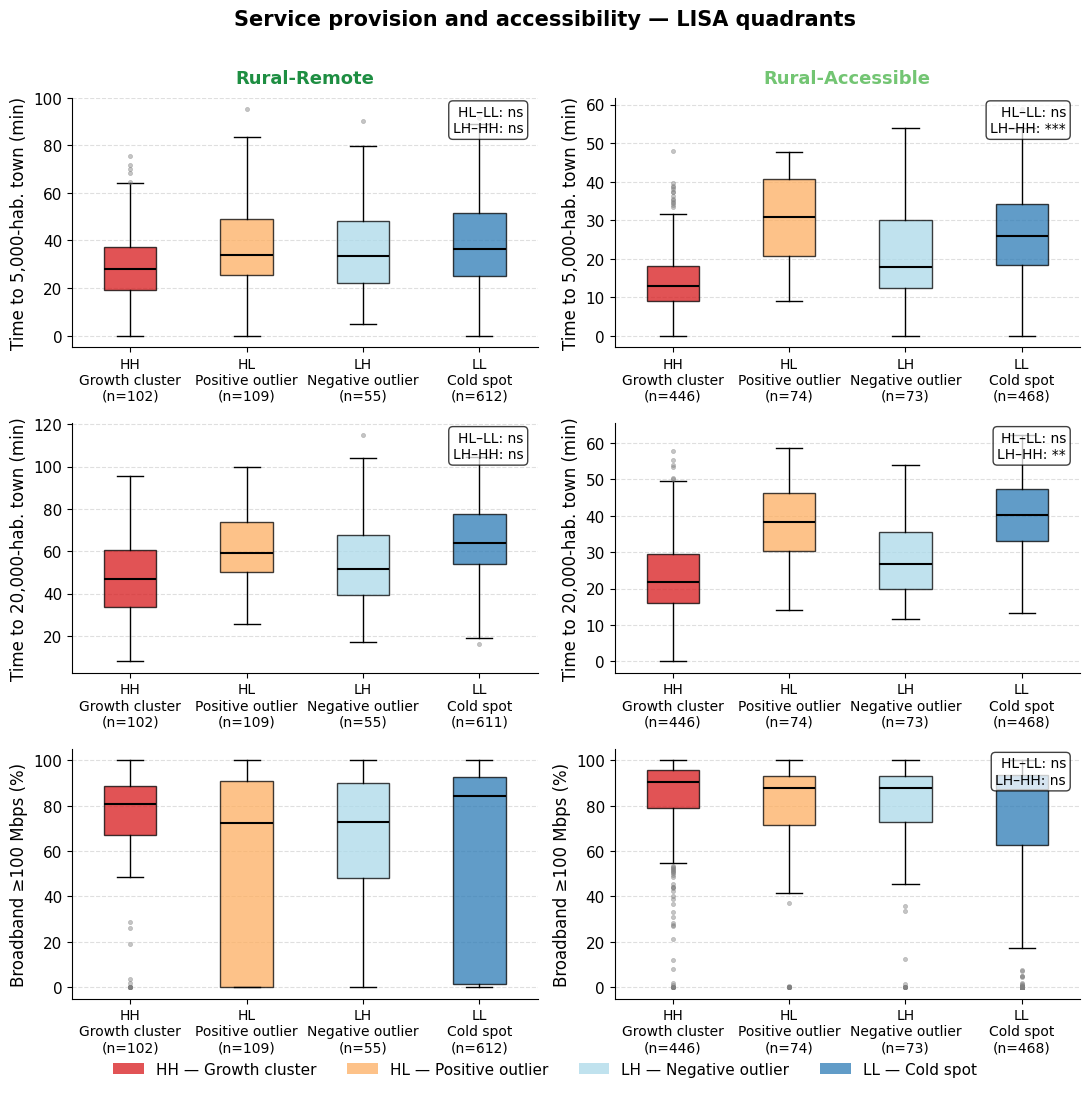

  ✓  p5a_lisa_remote_vs_accessible_services.png


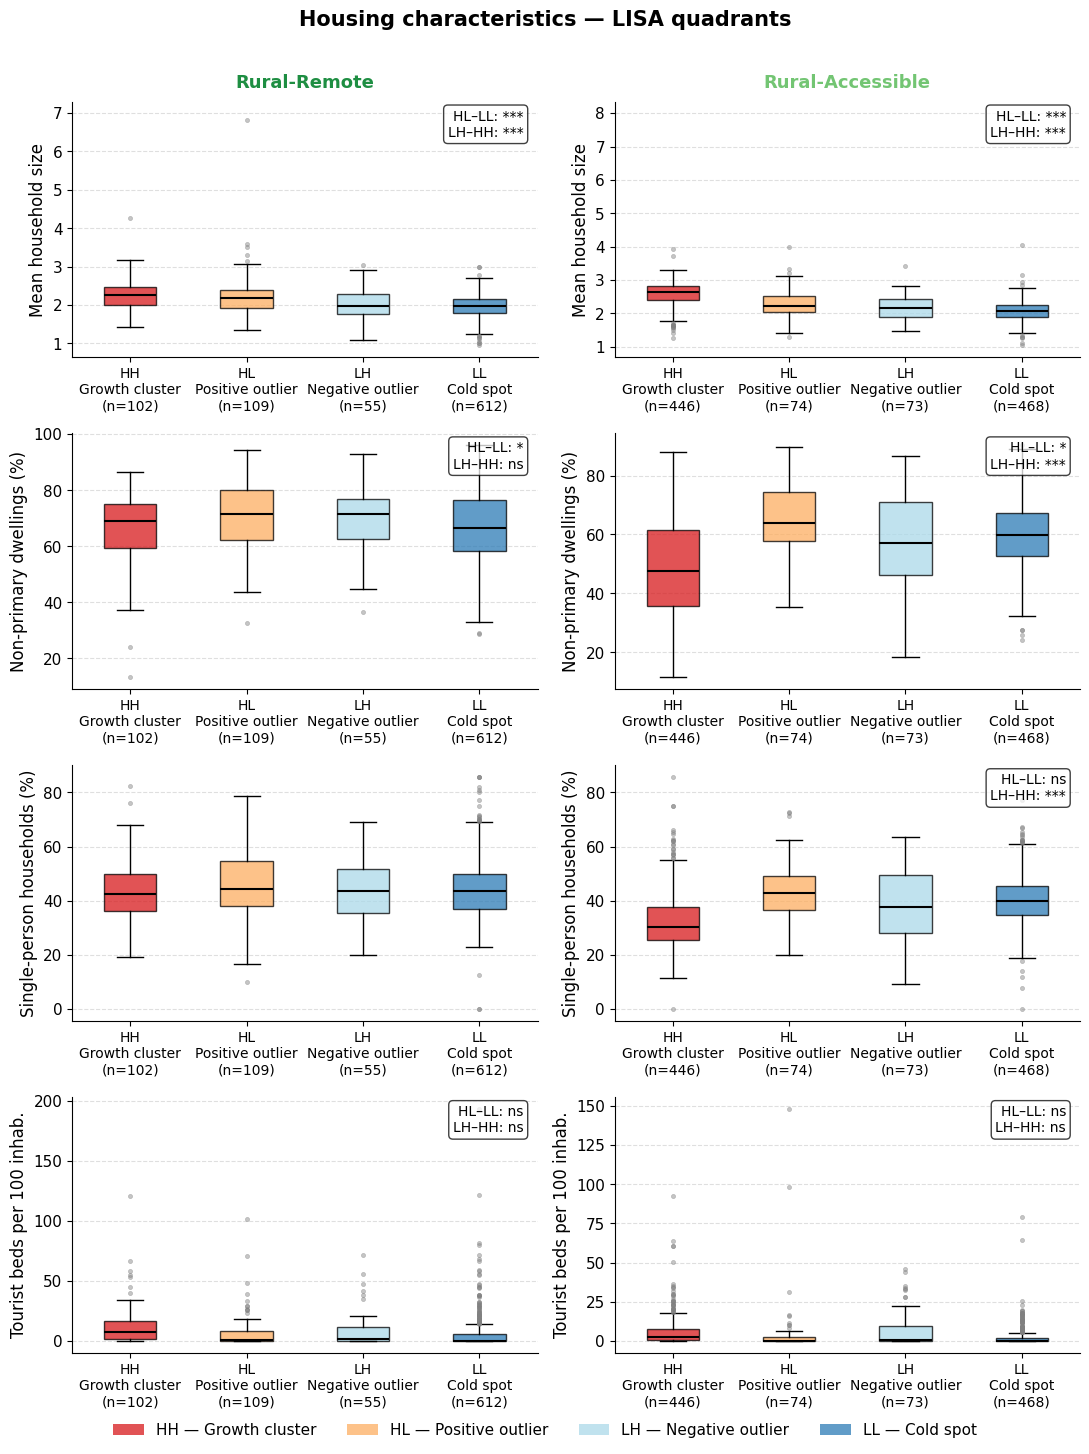

  ✓  p5a_lisa_remote_vs_accessible_housing.png


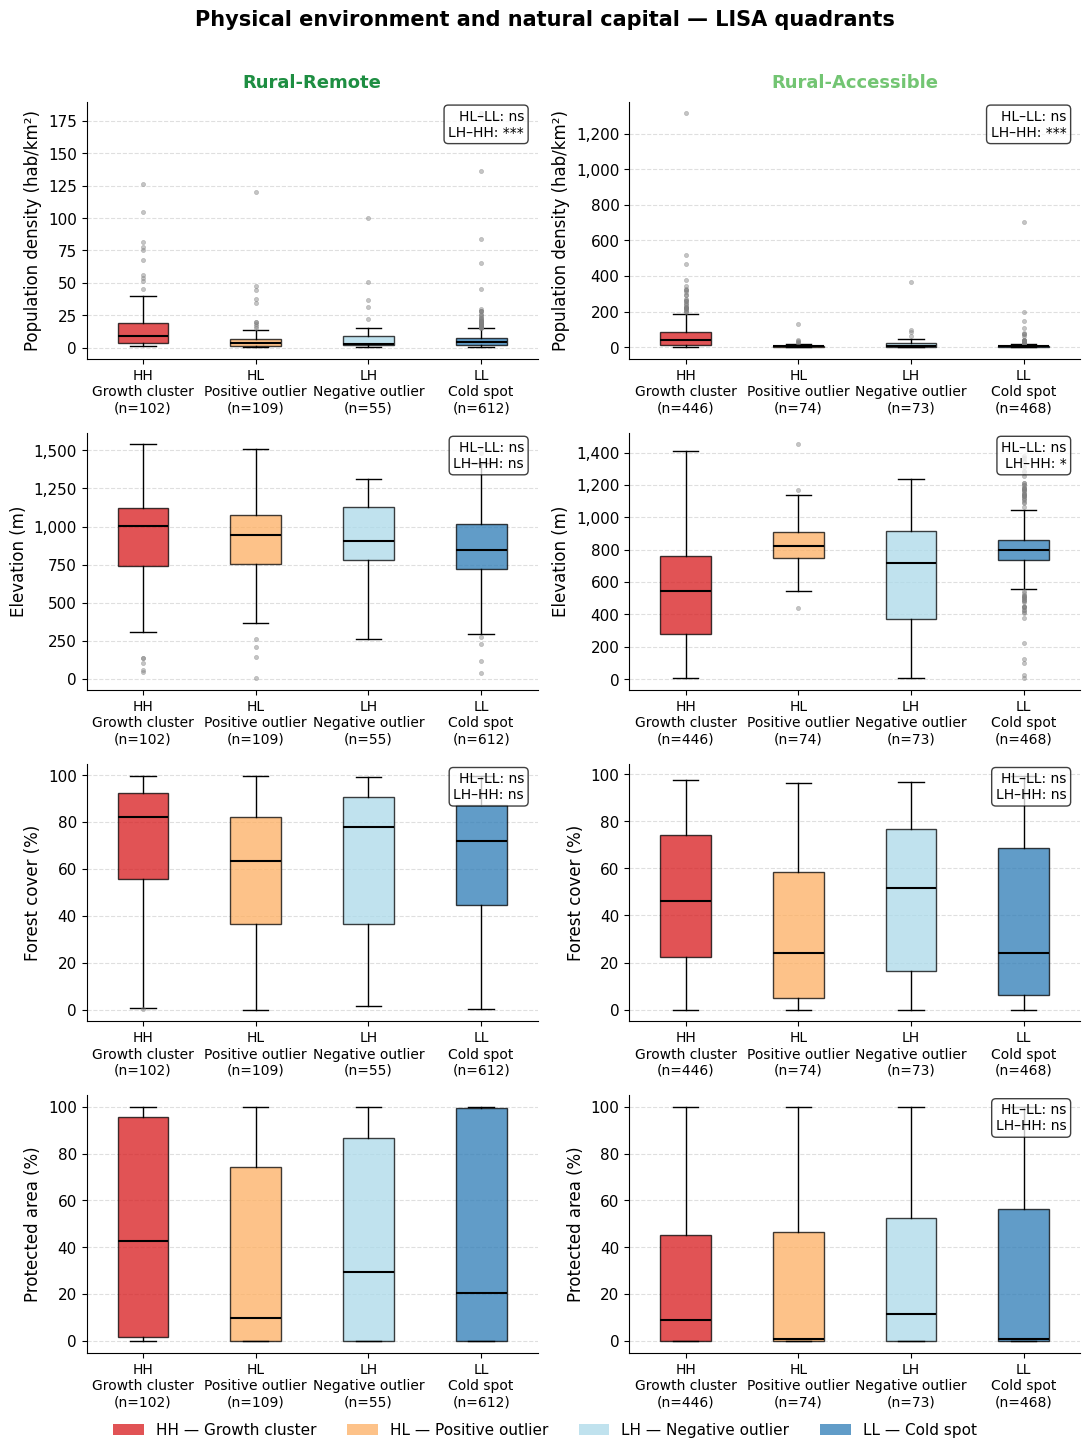

  ✓  p5a_lisa_remote_vs_accessible_physical_environment.png


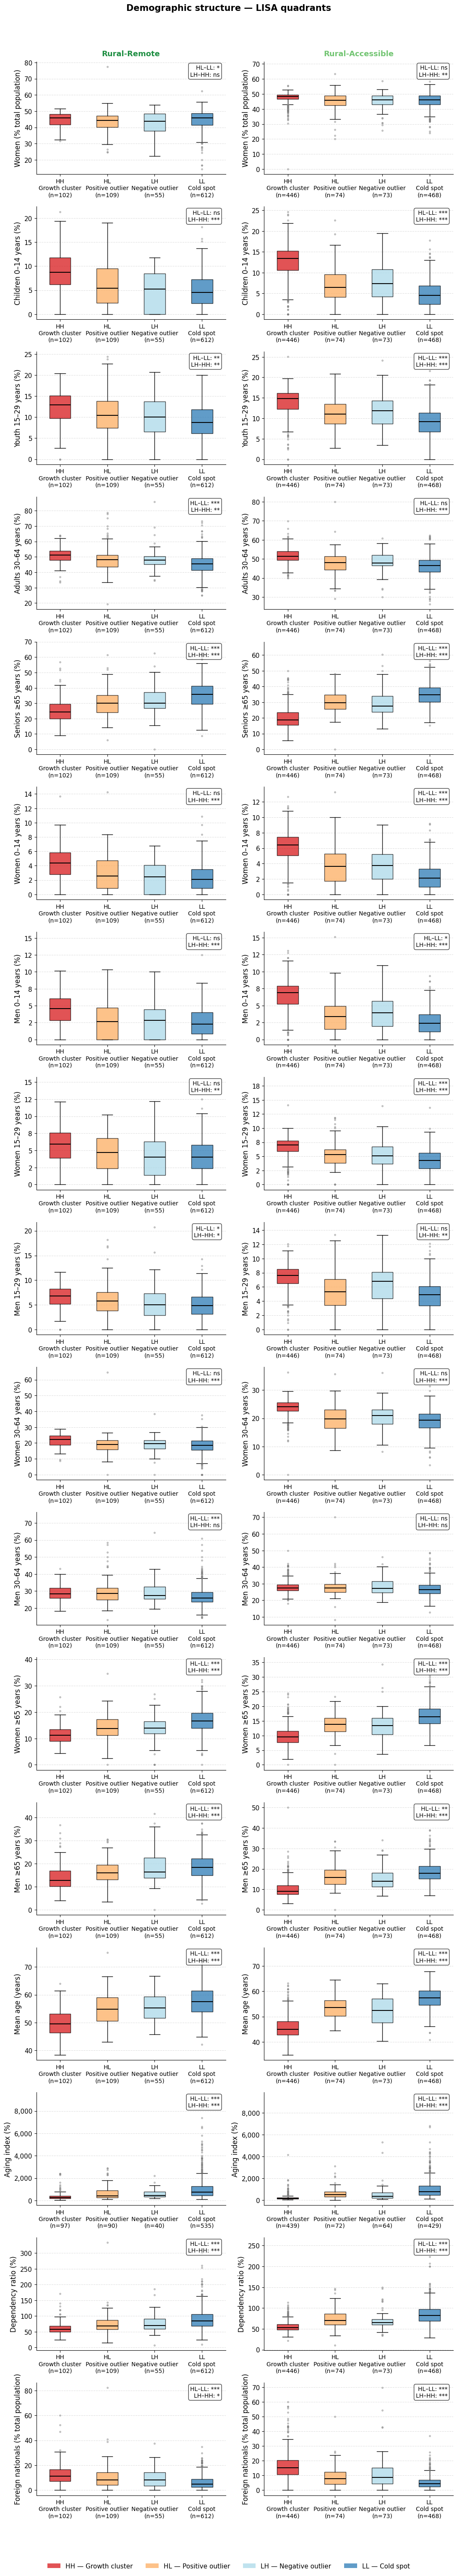

  ✓  p5a_lisa_remote_vs_accessible_demographic.png


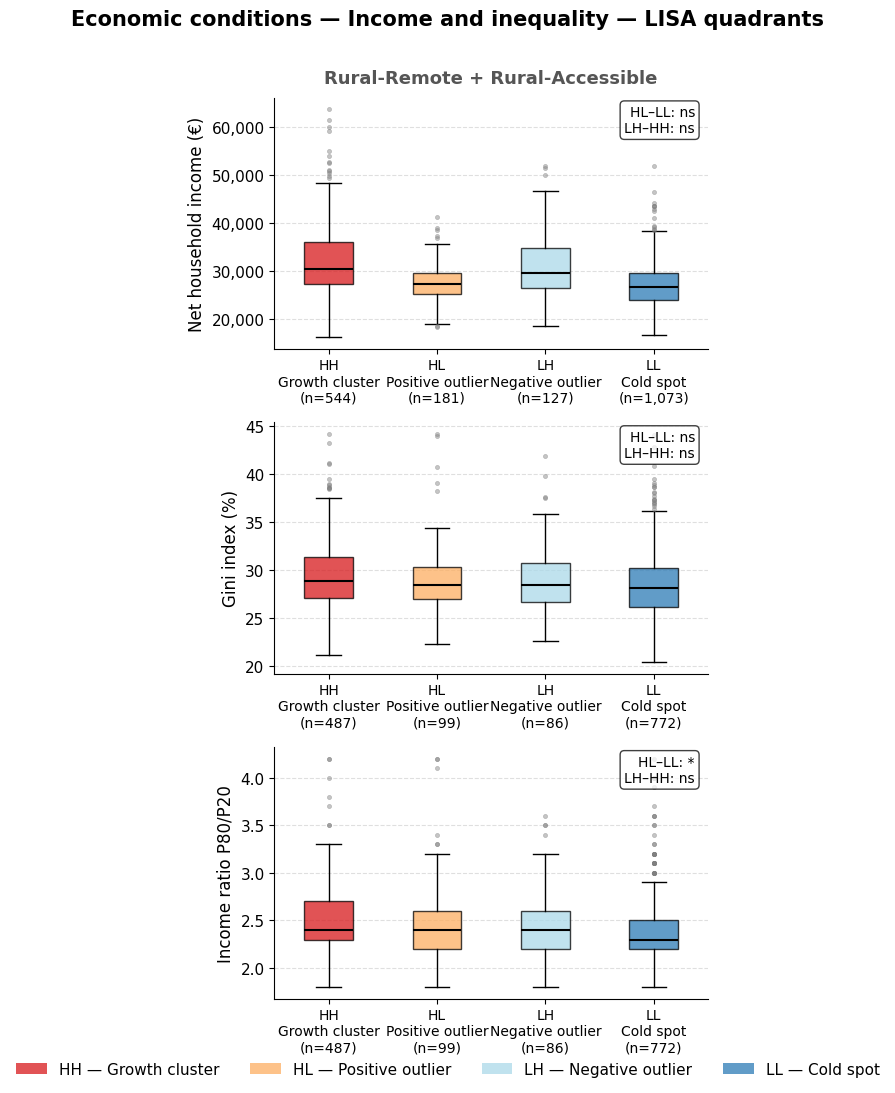

  ✓  p5a_lisa_combined_economic_income.png


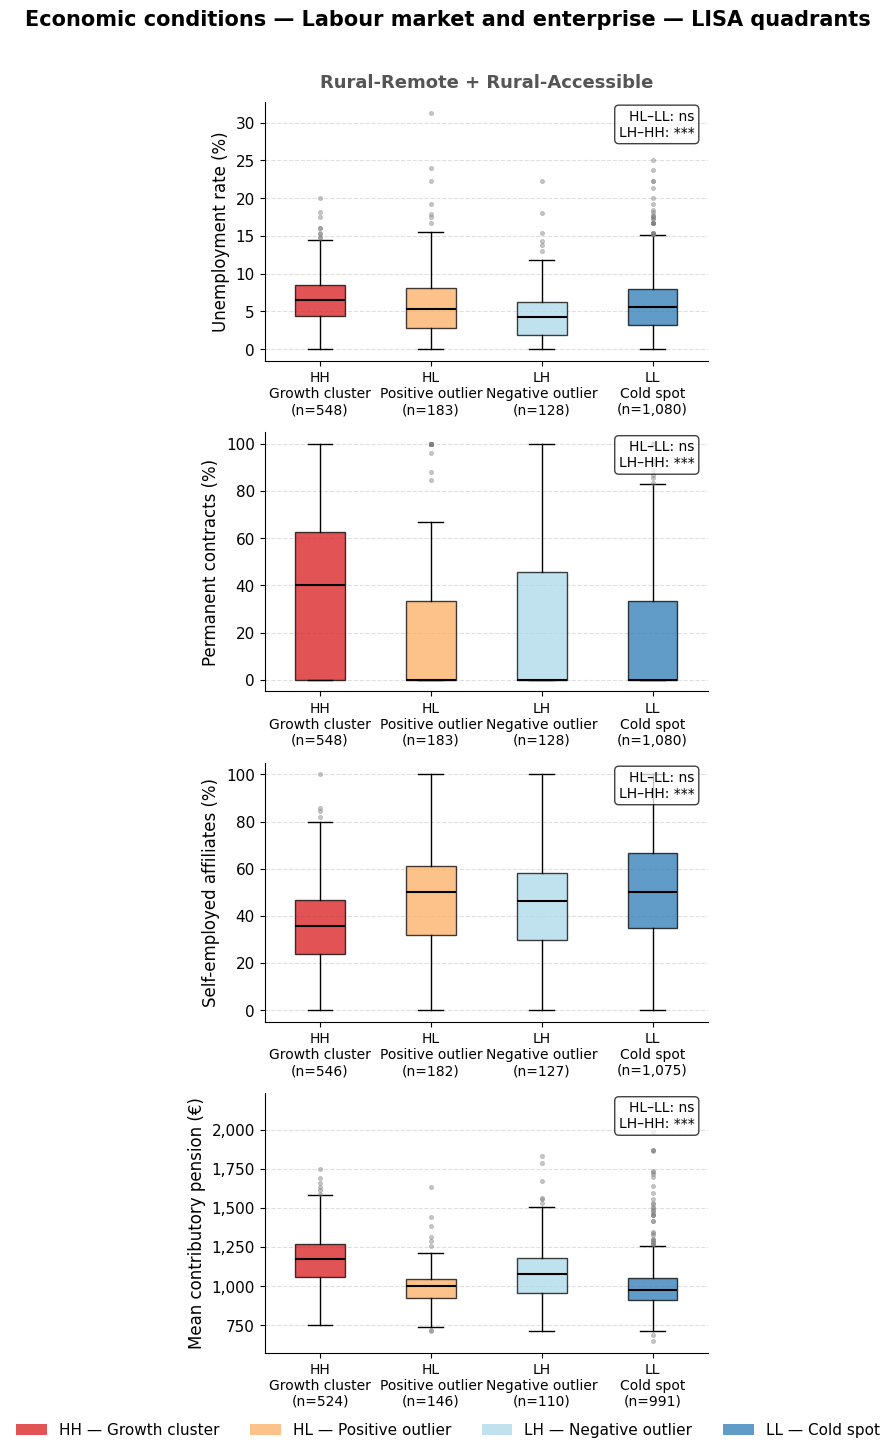

  ✓  p5a_lisa_combined_economic_labour.png


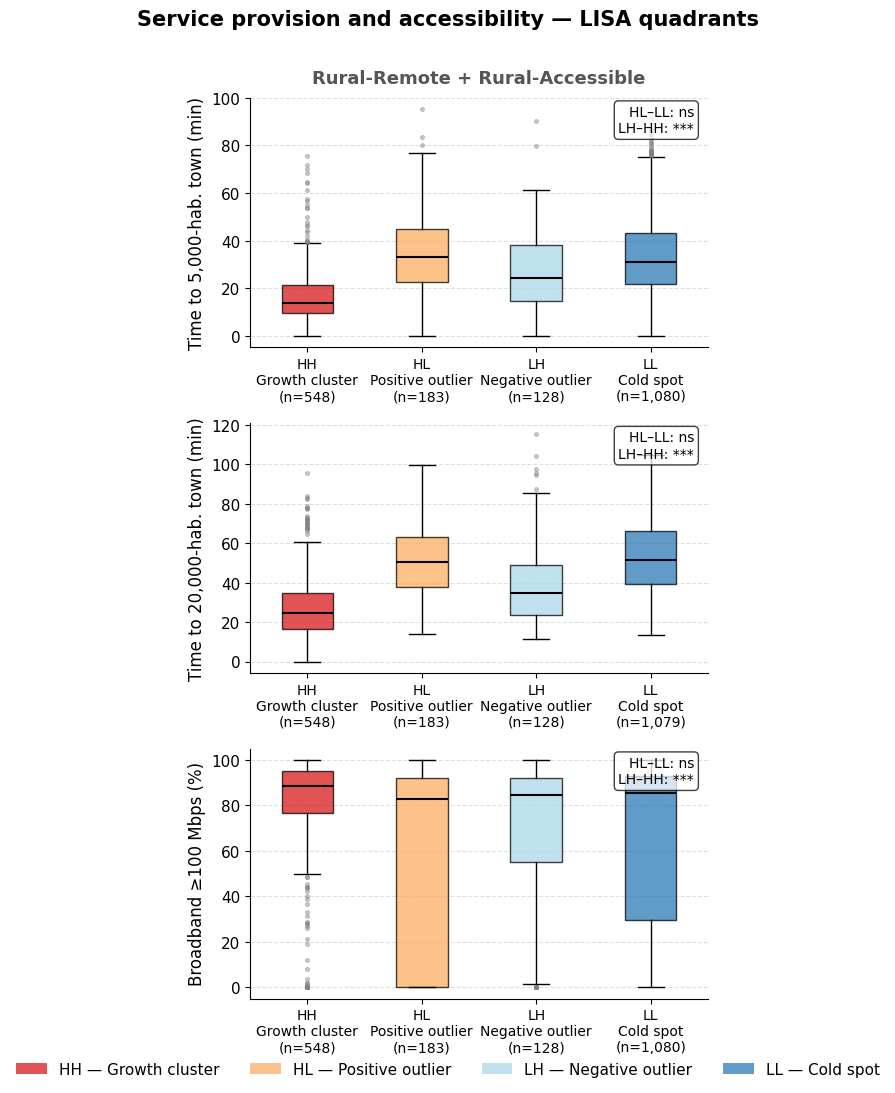

  ✓  p5a_lisa_combined_services.png


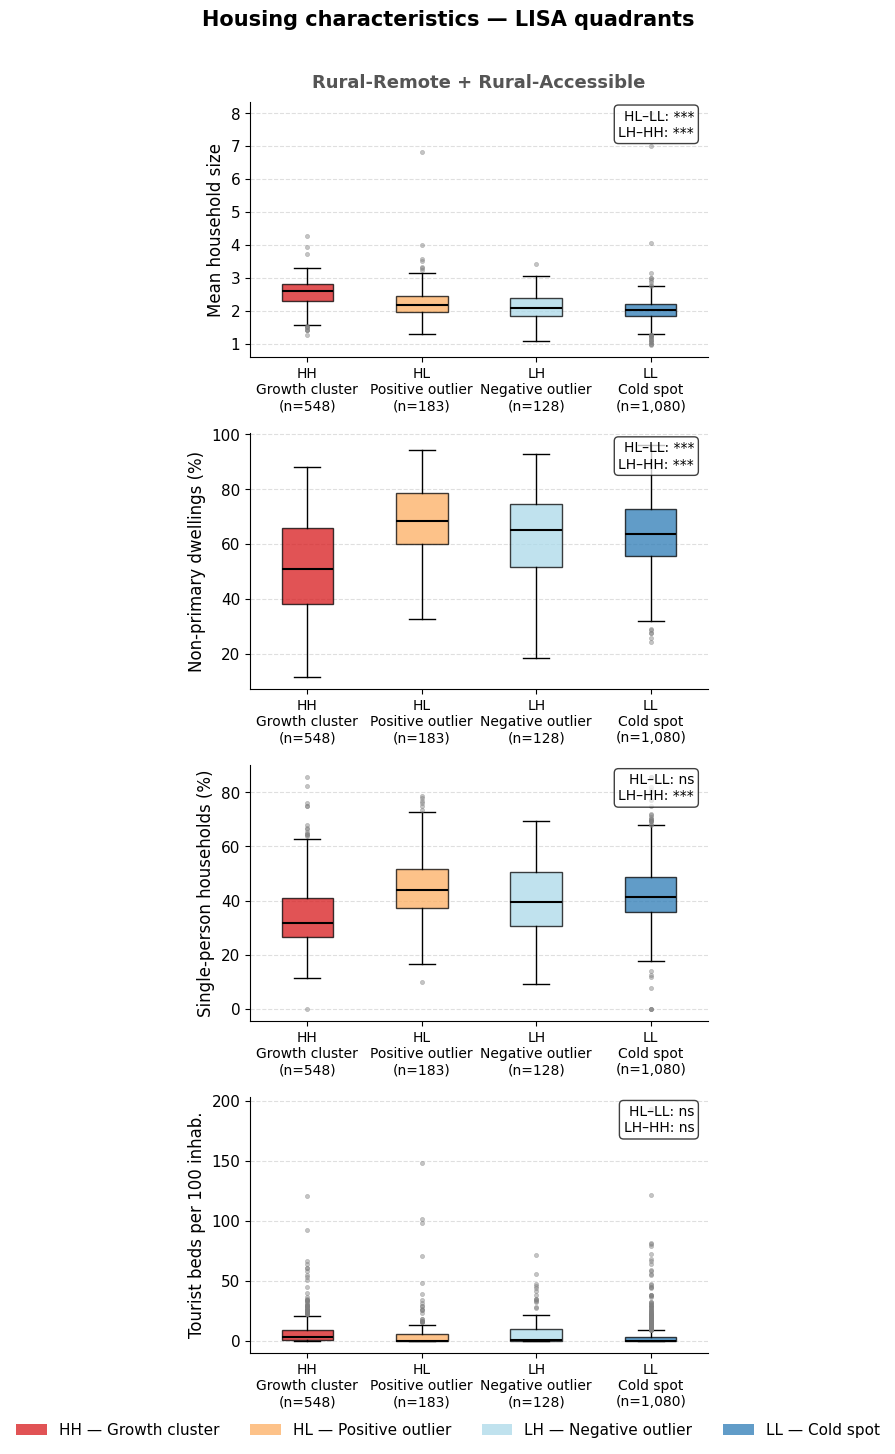

  ✓  p5a_lisa_combined_housing.png


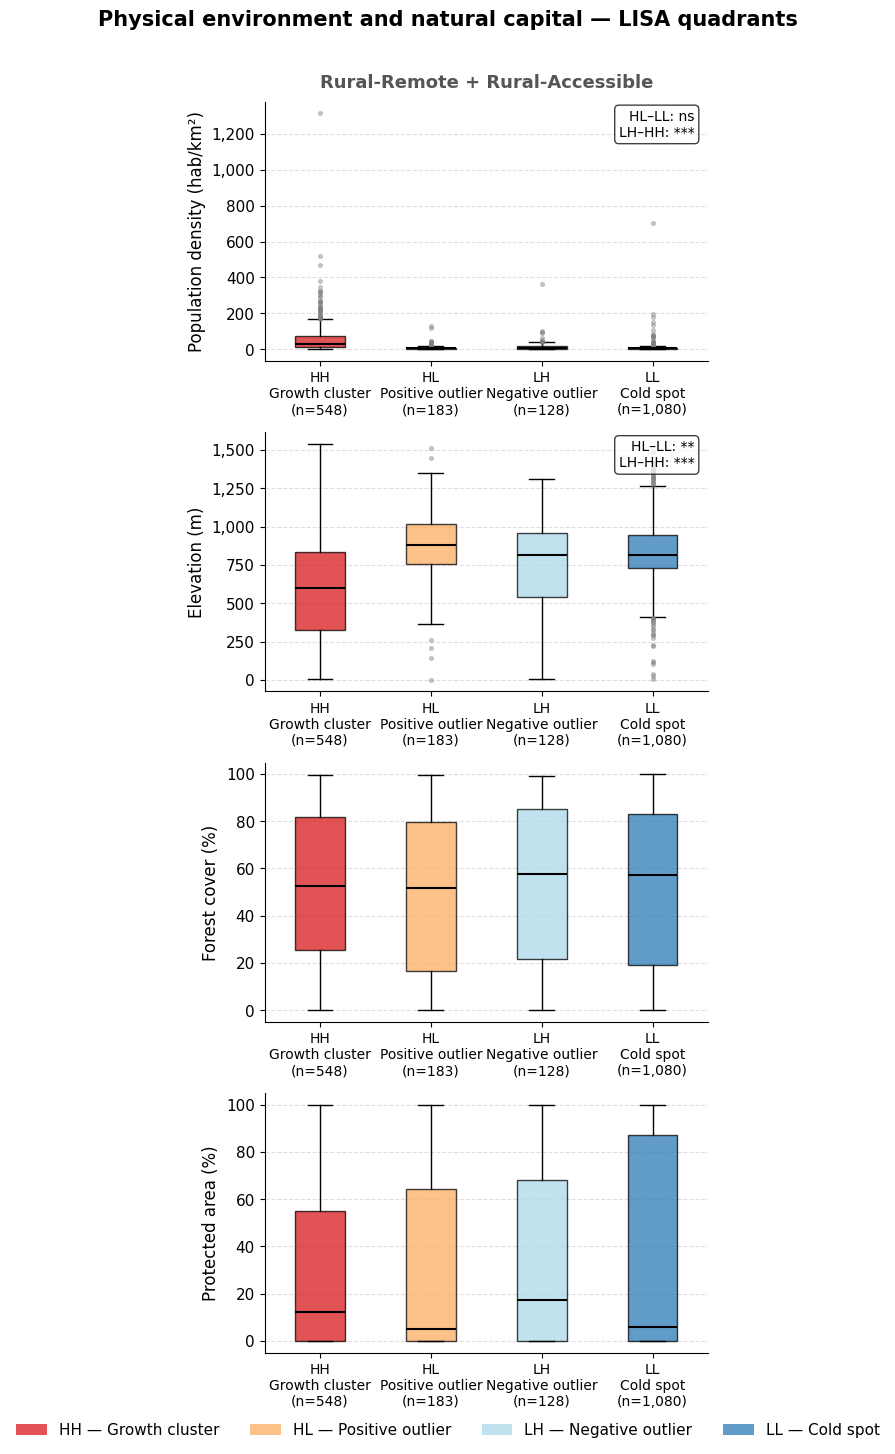

  ✓  p5a_lisa_combined_physical_environment.png


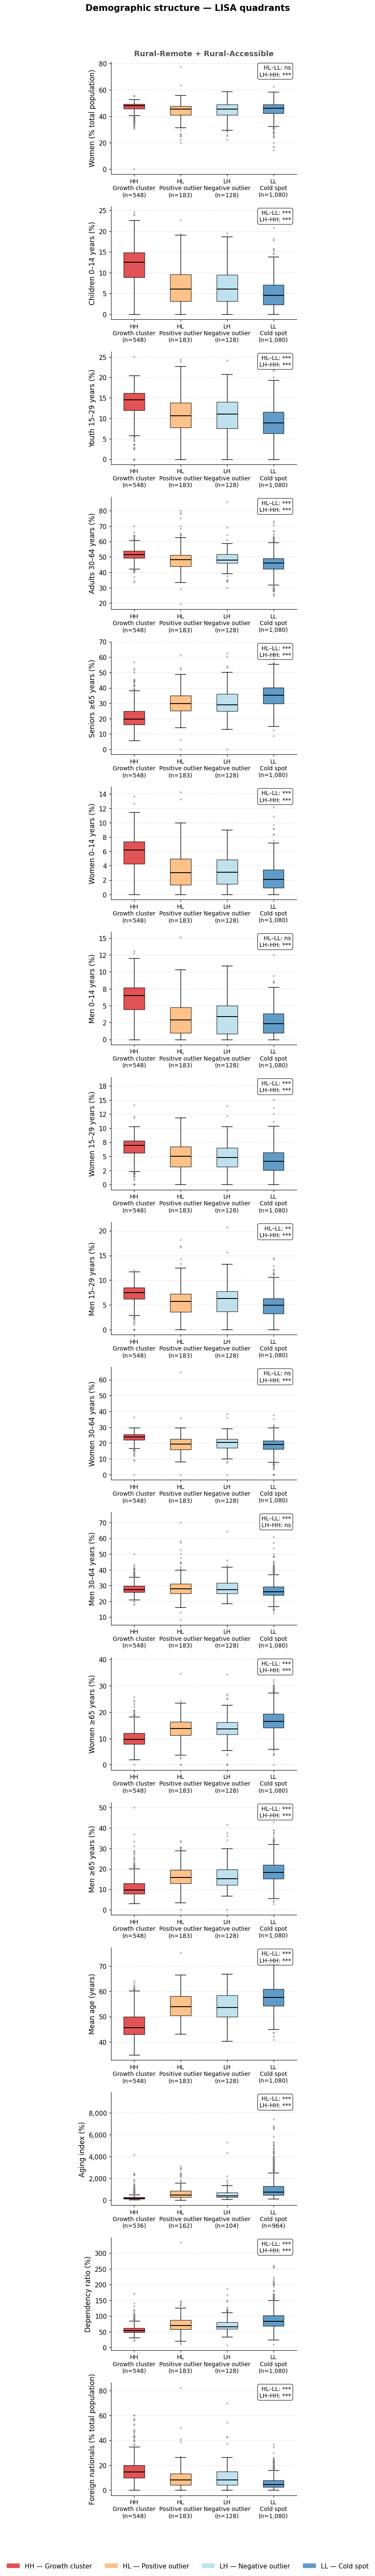

  ✓  p5a_lisa_combined_demographic.png

All figures saved to: C:\Users\juanz\OneDrive\Desktop\UCM\RURIM ESCAPE\GeoSpatial\01_Python Data Analysis\rural-migration-land-use-spain\figures\p5a_lisa_spatial_outliers


In [13]:
# ── 4.2 Figure loop ───────────────────────────────────────────────────────────

FIGURE_SETS = [
    {'name': 'remote_vs_accessible',
     'strata_cols': ['Rural-Remote', 'Rural-Accessible'],
     'col_labels':  ['Rural-Remote', 'Rural-Accessible'],
     'col_colors':  ['#1e8e42', '#73c573']},
    {'name': 'combined',
     'strata_cols': ['Rural-Combined'],
     'col_labels':  ['Rural-Remote + Rural-Accessible'],
     'col_colors':  ['#555555']},
]

for fig_set in FIGURE_SETS:
    n_cols = len(fig_set['strata_cols'])

    for fig_group in FIGURE_GROUPS:
        vars_in_group = [v for v in fig_group['vars'] if v in df_sig.columns]
        if not vars_in_group:
            continue

        n_rows = len(vars_in_group)
        fig, axes = plt.subplots(n_rows, n_cols,
                                  figsize=(5.5 * n_cols, 3.5 * n_rows),
                                  squeeze=False)

        for row_idx, var in enumerate(vars_in_group):
            label_en = get_label(var)
            scale    = PROPORTION_VARS.get(var, 1)

            for col_idx, stratum_name in enumerate(fig_set['strata_cols']):
                ax = axes[row_idx, col_idx]
                typology_val = STRATA[stratum_name]
                df_s = df_sig if typology_val is None else df_sig[df_sig['tipo_goerlich'] == typology_val]

                quads_present = [
                    q for q in QUAD_ORDER
                    if len(df_s[df_s['lisa_sig_quad'] == q][var].dropna()) >= 3
                ]
                if not quads_present:
                    ax.set_visible(False)
                    continue

                data_per_quad = [
                    df_s[df_s['lisa_sig_quad'] == q][var].dropna().values * scale
                    for q in quads_present
                ]

                bp = ax.boxplot(
                    data_per_quad, patch_artist=True, showfliers=True,
                    flierprops=dict(marker='o', ms=3, alpha=0.45, markeredgewidth=0.5, markerfacecolor='grey', markeredgecolor='grey'),
                    medianprops=dict(color='black', lw=1.5),
                    whiskerprops=dict(lw=1.0), capprops=dict(lw=1.0),
                )
                for patch, q in zip(bp['boxes'], quads_present):
                    patch.set_facecolor(QUAD_COLORS[q])
                    patch.set_alpha(0.75)

                n_per_quad = [
                    len(df_s[df_s['lisa_sig_quad'] == q][var].dropna())
                    for q in quads_present
                ]
                ax.set_xticklabels(
                    [f'{q}\n{QUAD_DESCRIPTIONS[q]}\n(n={n:,})'
                     for q, n in zip(quads_present, n_per_quad)],
                    fontsize=FONTSIZE - 2
                )

                if row_idx == 0:
                    ax.set_title(fig_set['col_labels'][col_idx],
                                 fontsize=FONTSIZE + 1, fontweight='bold',
                                 color=fig_set['col_colors'][col_idx], pad=10)

                ax.set_ylabel(label_en, fontsize=FONTSIZE)
                ax.tick_params(axis='y', labelsize=FONTSIZE - 1)
                ax.grid(axis='y', linestyle='--', alpha=0.4)
                ax.spines[['top', 'right']].set_visible(False)

                all_vals = np.concatenate(data_per_quad)
                yrange = all_vals.max() - all_vals.min() if len(all_vals) > 0 else 1
                if yrange < 3:
                    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
                else:
                    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

                add_lisa_annotation(ax, stratum_name, var, quads_present)

        legend_patches = [
            mpatches.Patch(facecolor=QUAD_COLORS[q], alpha=0.75,
                           label=f'{q} — {QUAD_DESCRIPTIONS[q]}')
            for q in QUAD_ORDER
        ]
        fig.legend(handles=legend_patches, loc='lower center', ncol=4,
                   fontsize=FONTSIZE - 1, frameon=False, bbox_to_anchor=(0.5, -0.02))

        fig.suptitle(
            f"{fig_group['suptitle']} — LISA quadrants",
            fontsize=FONTSIZE + 3, fontweight='bold', y=1.01
        )
        plt.tight_layout()

        fname = FIG_DIR / f"p5a_lisa_{fig_set['name']}_{fig_group['label']}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'  ✓  {fname.name}')
        plt.close()

print(f'\nAll figures saved to: {FIG_DIR}')

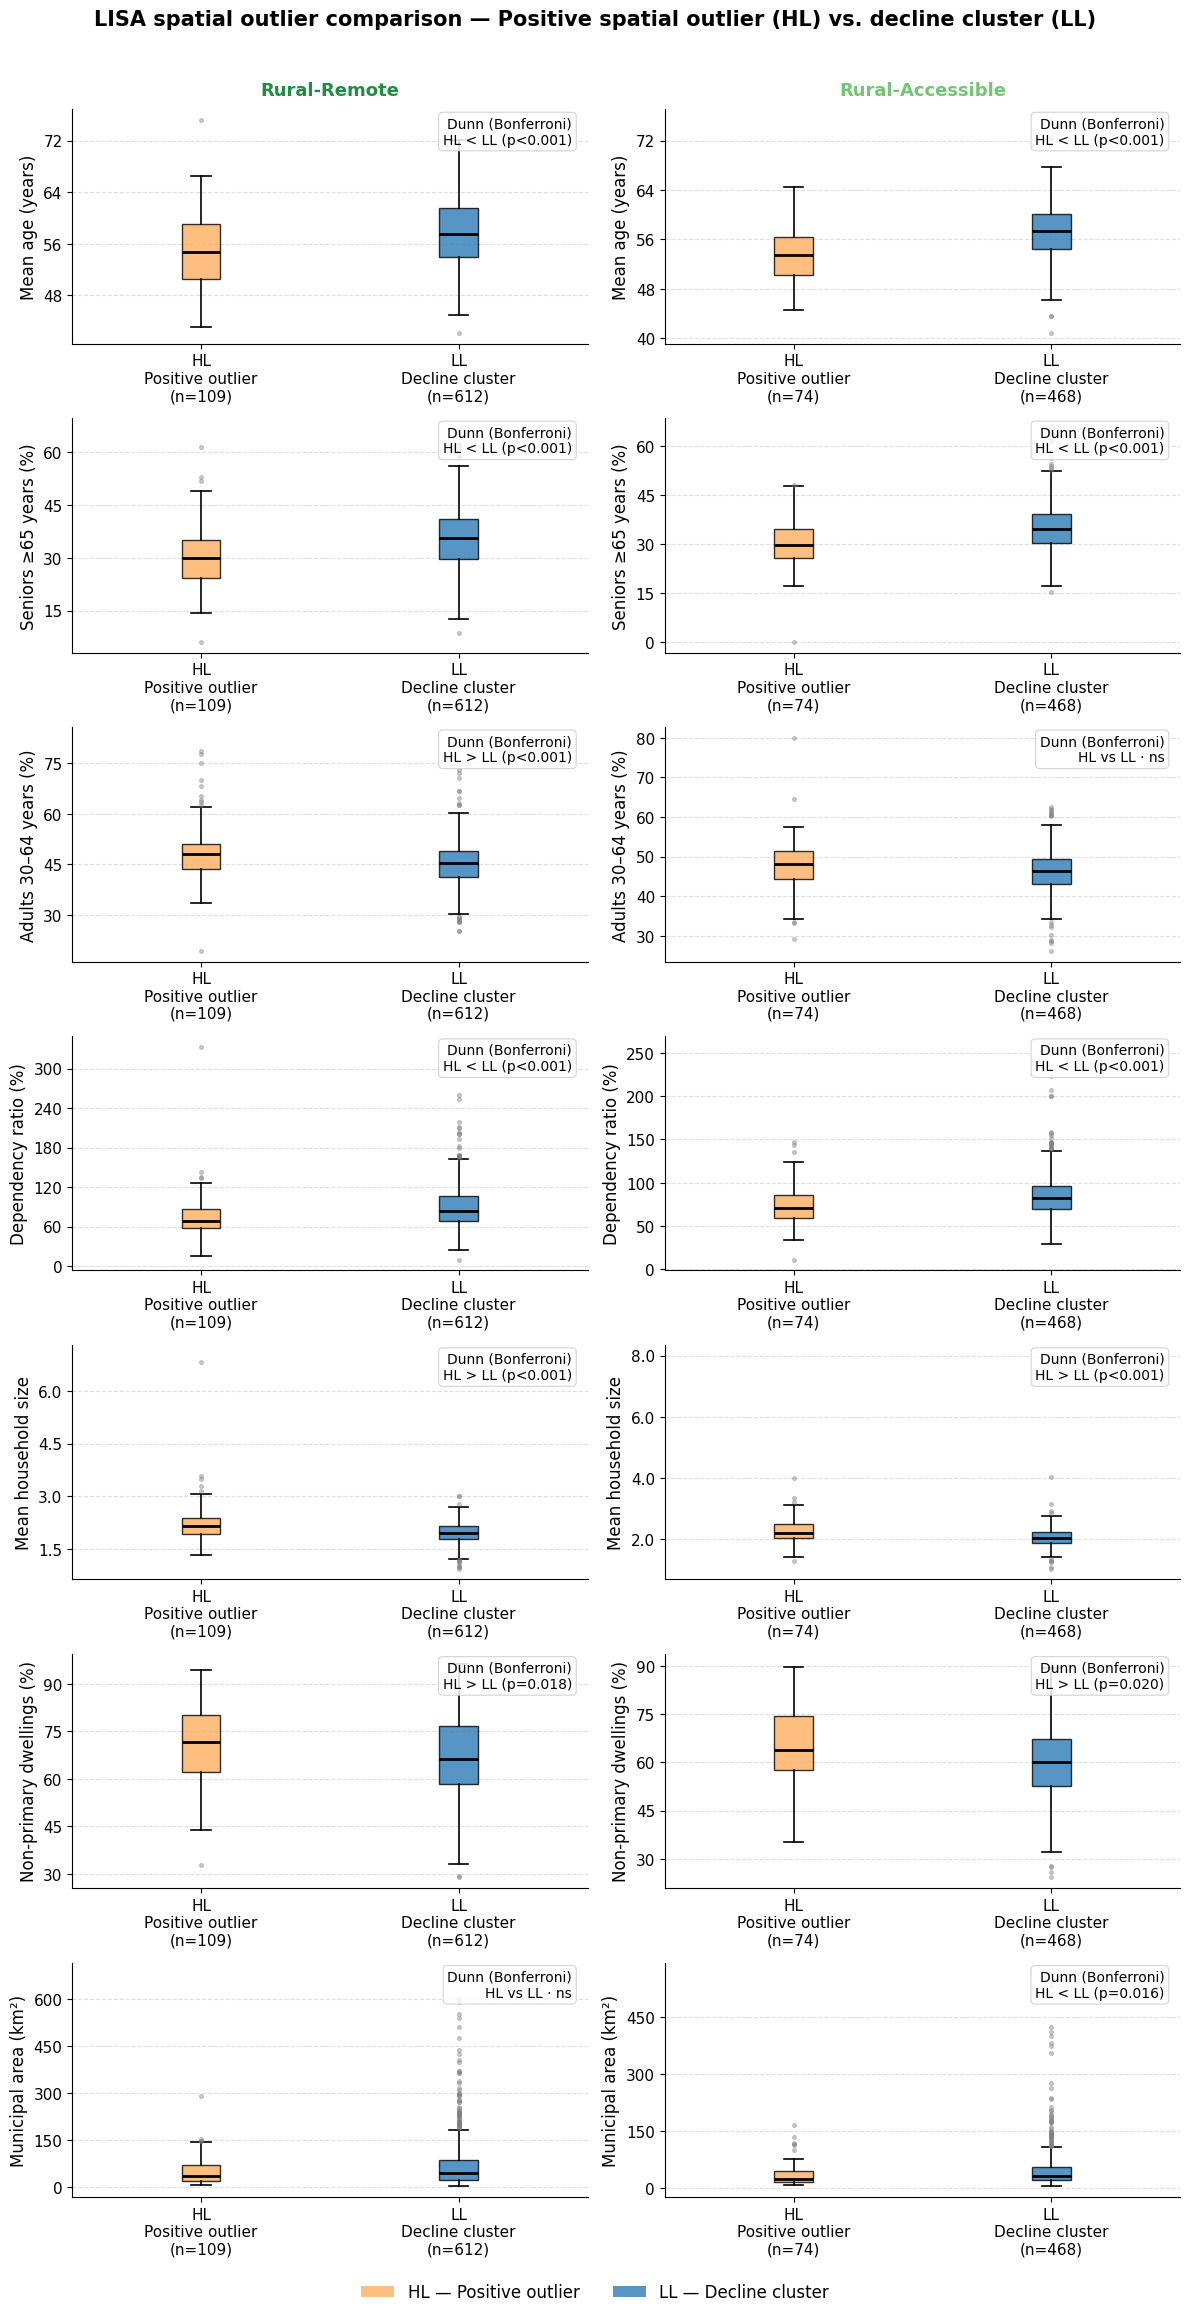

  ✓  00_p5a_lisa_focused_HL_vs_LL_main.png


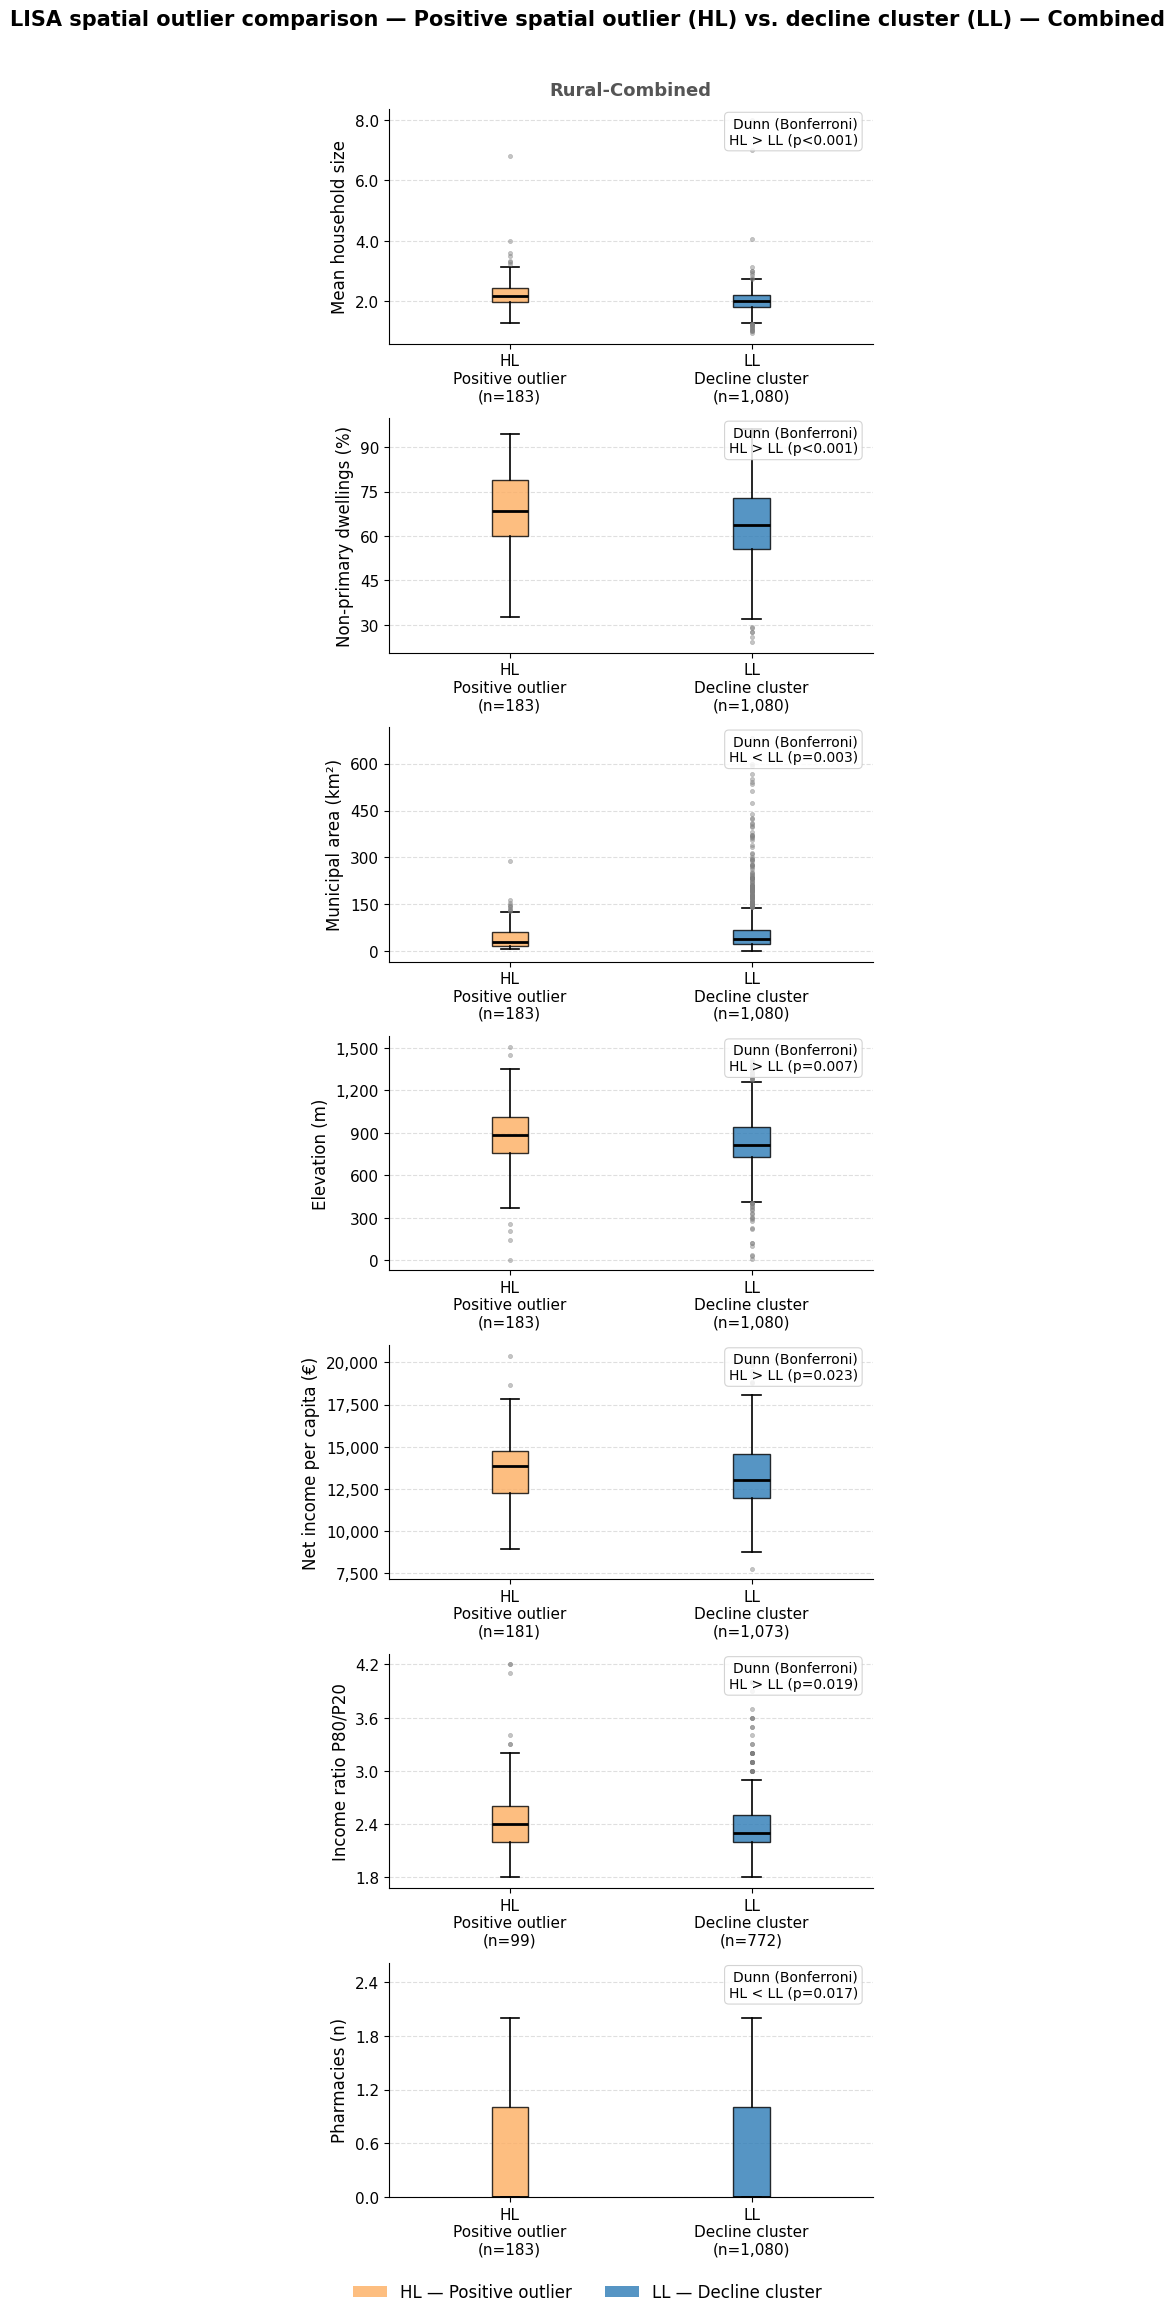

  ✓  00_p5a_lisa_focused_HL_vs_LL_supplementary_combined.png


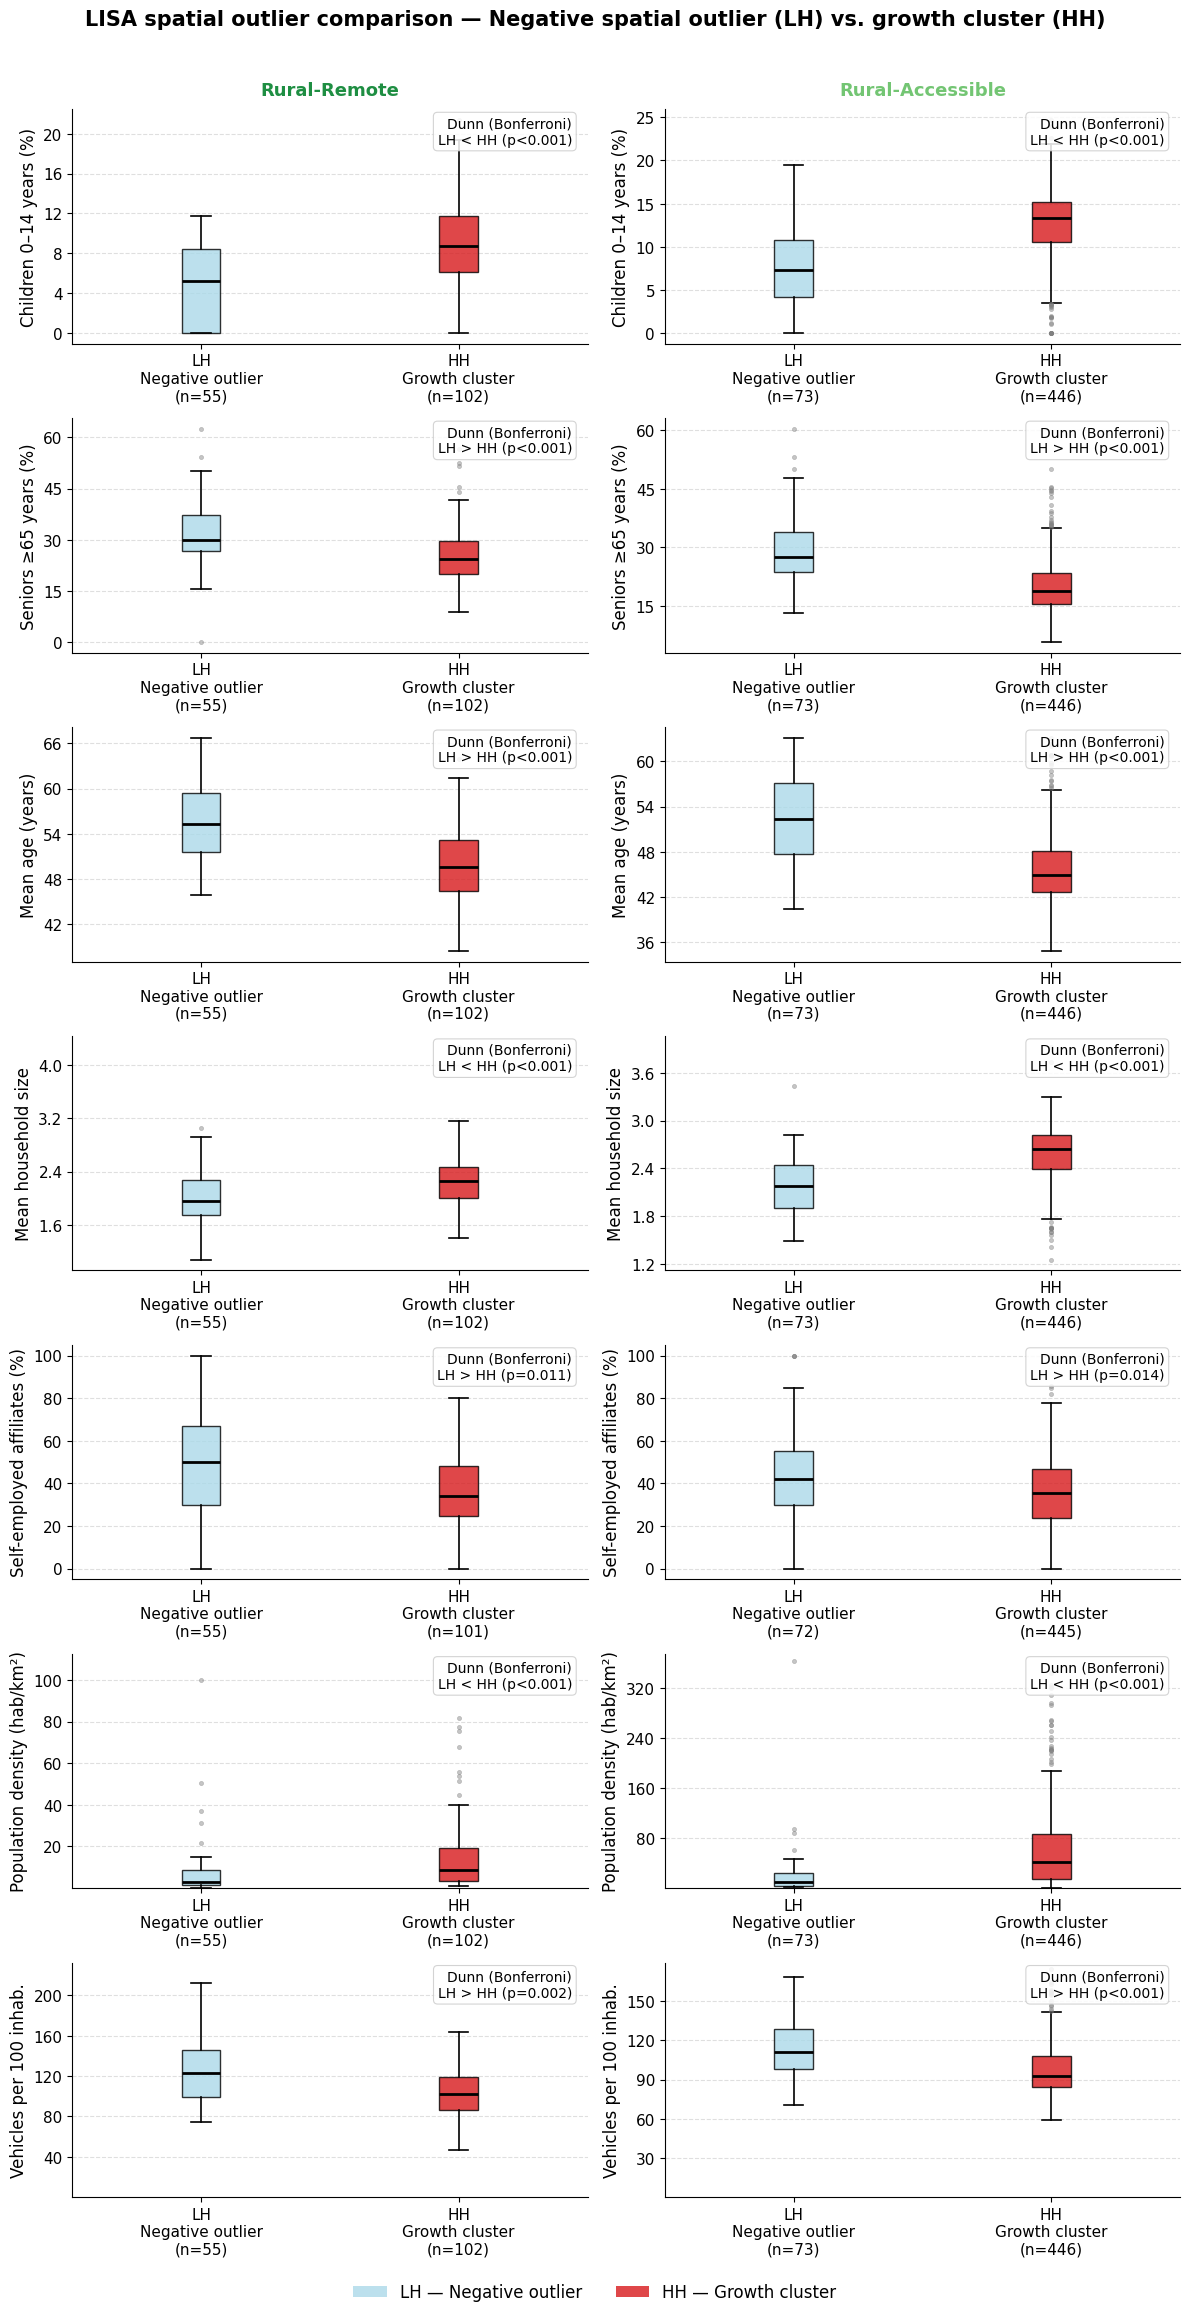

  ✓  00_p5a_lisa_focused_LH_vs_HH_main.png


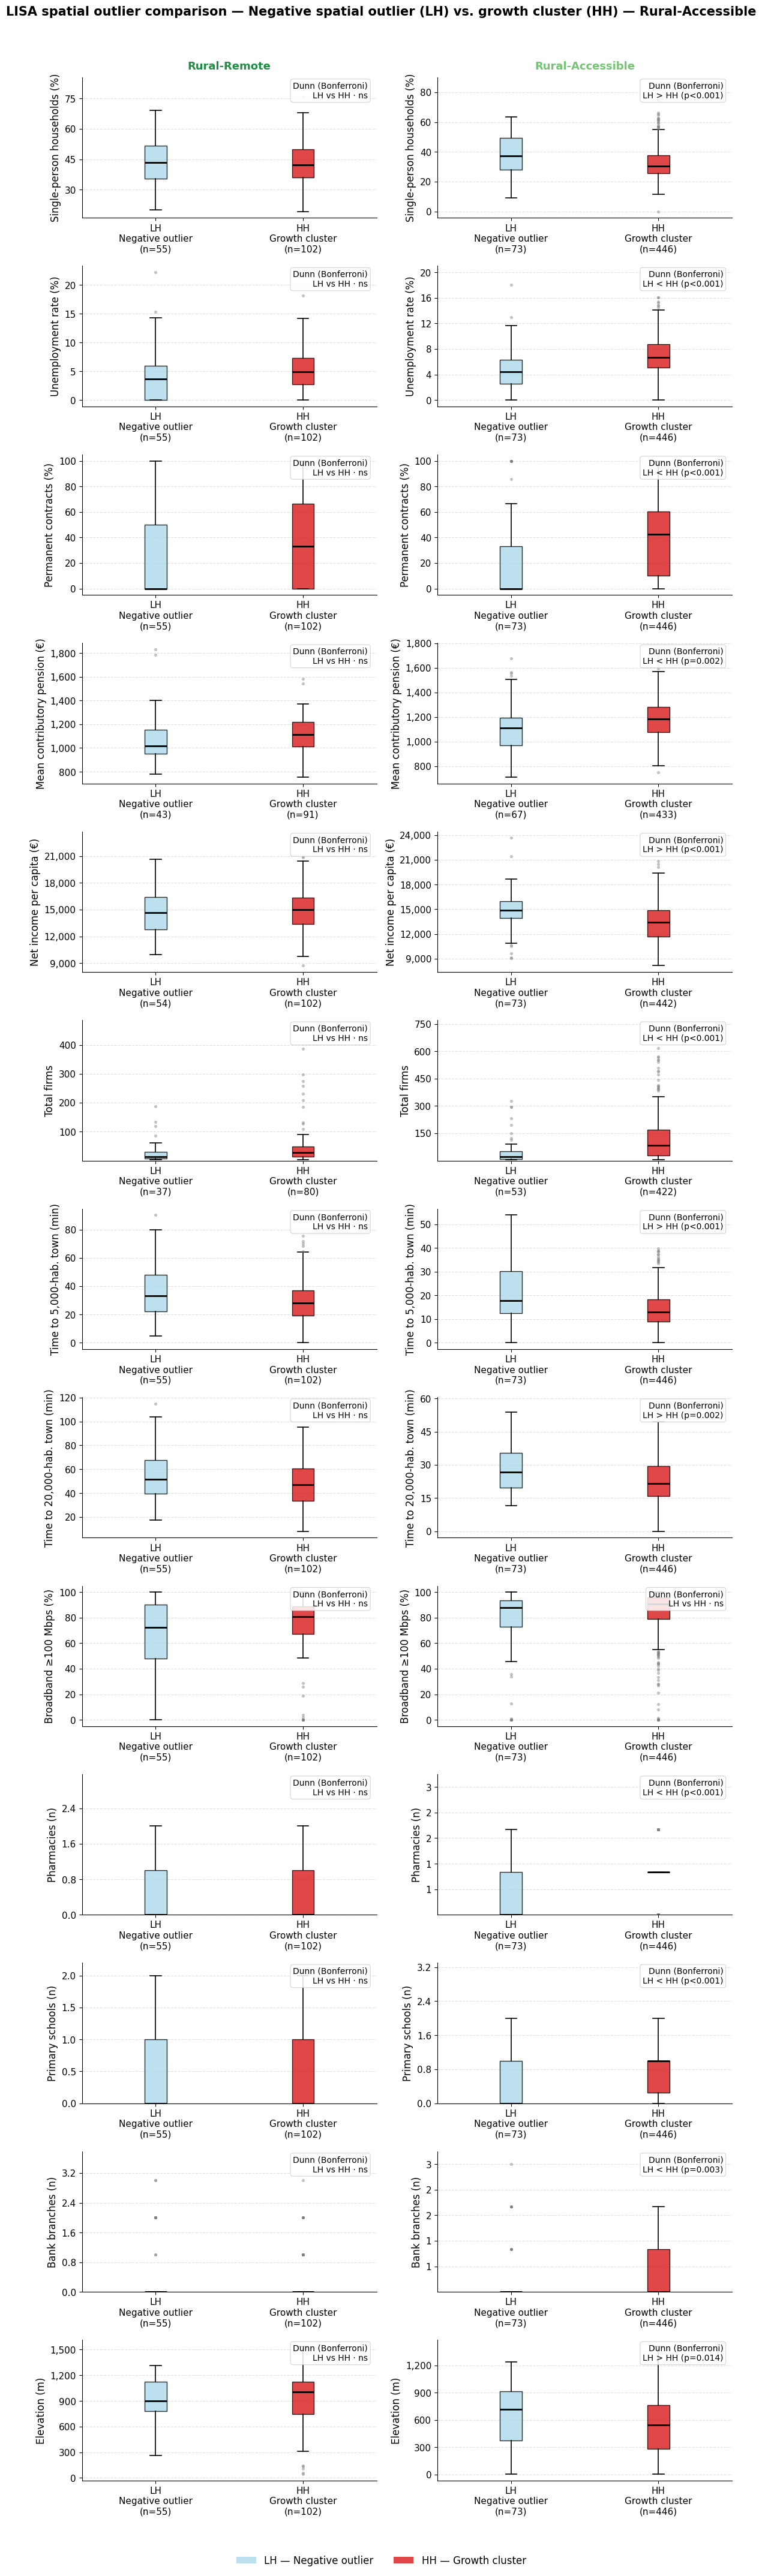

  ✓  00_p5a_lisa_focused_LH_vs_HH_secondary.png


In [14]:
# ── Focused comparison figures: HL vs. LL and LH vs. HH ──────────────────────
# Figure structure:
#   HL vs. LL  — main:        significant in Remote AND/OR Accessible
#   HL vs. LL  — supplementary (Combined): significant in Combined only
#   LH vs. HH  — main:        significant in BOTH Remote AND Accessible
#   LH vs. HH  — secondary:   significant in ONE stratum only (mostly Accessible)
# All figures: Remote (left) | Accessible (right)
# Supplementary Combined figures: single column
# "Cold spot" replaced by "Decline cluster" throughout.

# ── Variable lists ────────────────────────────────────────────────────────────

VARS_HL_LL_MAIN = [
    'DEMOGRAFIA__EDAD MEDIA__Edad media población',
    'DEMOGRAFIA__Pct_65_plus',
    'DEMOGRAFIA__Pct_30_64',
    'DEMOGRAFIA__RATIOS__Tasa dependencia \n(%)',
    'VIVIENDA__HOGAR__Tamaño medio del hogar',
    'VIVIENDA__TIPOS DE VIVIENDAS (familiares)__Viviendas no principales (% s/ total)',
    'MEDIO FÍSICO__Superficie (km2)',
]

VARS_HL_LL_SUPP = [
    'VIVIENDA__HOGAR__Tamaño medio del hogar',
    'VIVIENDA__TIPOS DE VIVIENDAS (familiares)__Viviendas no principales (% s/ total)',
    'MEDIO FÍSICO__Superficie (km2)',
    'MEDIO FÍSICO__Altitud capital \n(m)',
    'ECONOMIA__RENTAS__Renta neta media por persona',
    'ECONOMIA__RENTAS__DESIGUALDAD__Distribución de la renta P80/P20',
    'SERVICIOS__ESTABLECIMIENTOS SANITARIOS__Oficina de farmacia (número)',
]

VARS_LH_HH_MAIN = [
    'DEMOGRAFIA__Pct_0_14',
    'DEMOGRAFIA__Pct_65_plus',
    'DEMOGRAFIA__EDAD MEDIA__Edad media población',
    'VIVIENDA__HOGAR__Tamaño medio del hogar',
    'ECONOMIA__AFILIADOS__POR SECTOR__Afiliados Régimen Especial (R. E.) T. Autónomos \n(% s/ Total)',
    'MEDIO FÍSICO__Densidad (hab/km2)',
    'SERVICIOS__TRANSPORTE__Parque de vehículos x c/ 100 hab.',
]

VARS_LH_HH_SEC = [
    'VIVIENDA__HOGAR__Hogares unipersonales \n(% s/ total)',
    'ECONOMIA__PARADOS__POR SEXO__Tasa de paro',
    'ECONOMIA__CONTRATOS__POR DURACIÓN__Contratos indefinidos \n(% s/ Total)',
    'ECONOMIA__PENSIONES CONTRIBUTIVAS__Pensión Contributiva Media',
    'ECONOMIA__RENTAS__Renta neta media por persona',
    'ECONOMIA__EMPRESAS__Total Empresas',
    'SERVICIOS__DISTANCIAS A LOS SERVICIOS MÁS CERCANOS__Tiempo municipio 5.000 hab. o más, más cercano (minutos)',
    'SERVICIOS__DISTANCIAS A LOS SERVICIOS MÁS CERCANOS__Tiempo municipio 20.000 hab. o más, más cercano (minutos)',
    'SERVICIOS__INTERNET__Porcentaje cobertura ≥ 100 Mbps (condiciones máxima demanda)',
    'SERVICIOS__ESTABLECIMIENTOS SANITARIOS__Oficina de farmacia (número)',
    'SERVICIOS__CENTROS DE EDUCACIÓN__Nº centros de Educación Primaria',
    'SERVICIOS__OTROS SERVICIOS__SUCURSAL BANCARIA__Sucursal bancaria (número)',
    'MEDIO FÍSICO__Altitud capital \n(m)',
]

# ── Figure configurations ─────────────────────────────────────────────────────
# mode: 'two_col' = Remote | Accessible
#        'combined' = Combined only (supplementary)

FOCUSED_CONFIGS = [
    {
        'pair': ('HL', 'LL'),
        'vars': VARS_HL_LL_MAIN,
        'colors': [QUAD_COLORS['HL'], QUAD_COLORS['LL']],
        'fname': '00_p5a_lisa_focused_HL_vs_LL_main',
        'suptitle': 'Positive spatial outlier (HL) vs. decline cluster (LL)',
        'mode': 'two_col',
        'g2_label': 'Decline cluster',
    },
    {
        'pair': ('HL', 'LL'),
        'vars': VARS_HL_LL_SUPP,
        'colors': [QUAD_COLORS['HL'], QUAD_COLORS['LL']],
        'fname': '00_p5a_lisa_focused_HL_vs_LL_supplementary_combined',
        'suptitle': 'Positive spatial outlier (HL) vs. decline cluster (LL) — Combined',
        'mode': 'combined',
        'g2_label': 'Decline cluster',
    },
    {
        'pair': ('LH', 'HH'),
        'vars': VARS_LH_HH_MAIN,
        'colors': [QUAD_COLORS['LH'], QUAD_COLORS['HH']],
        'fname': '00_p5a_lisa_focused_LH_vs_HH_main',
        'suptitle': 'Negative spatial outlier (LH) vs. growth cluster (HH)',
        'mode': 'two_col',
        'g2_label': 'Growth cluster',
    },
    {
        'pair': ('LH', 'HH'),
        'vars': VARS_LH_HH_SEC,
        'colors': [QUAD_COLORS['LH'], QUAD_COLORS['HH']],
        'fname': '00_p5a_lisa_focused_LH_vs_HH_secondary',
        'suptitle': 'Negative spatial outlier (LH) vs. growth cluster (HH) — Rural-Accessible',
        'mode': 'two_col',
        'g2_label': 'Growth cluster',
    },
]

# ── Y-axis cap for variables with extreme outliers ────────────────────────────
YLIM_PCT_VARS = {
    'SERVICIOS__ESTABLECIMIENTOS SANITARIOS__Oficina de farmacia (número)': 99,
    'SERVICIOS__OTROS SERVICIOS__SUCURSAL BANCARIA__Sucursal bancaria (número)': 99,
    'ECONOMIA__EMPRESAS__Total Empresas': 99,
    'SERVICIOS__CENTROS DE EDUCACIÓN__Nº centros de Educación Primaria': 99,
    'SERVICIOS__TRANSPORTE__Parque de vehículos x c/ 100 hab.': 95,
    'MEDIO FÍSICO__Densidad (hab/km2)': 99,
}

PROPORTION_VARS = {
    'SERVICIOS__INTERNET__Porcentaje cobertura ≥ 100 Mbps (condiciones máxima demanda)': 100,
}

COL_COLORS = ['#1e8e42', '#73c573']

# ── Helper: annotation text ───────────────────────────────────────────────────
def get_annot_text(stratum_name, var, g1, g2, data_g1, data_g2):
    """Return Dunn annotation string. Always returns something (ns if not significant)."""
    med_g1_val = np.median(data_g1) if len(data_g1) > 0 else np.nan
    med_g2_val = np.median(data_g2) if len(data_g2) > 0 else np.nan
    default    = f'Dunn (Bonferroni)\n{g1} vs {g2} · ns'

    if len(df_dunn_all) == 0:
        return default

    df_local = df_dunn_all[
        (df_dunn_all['stratum'] == stratum_name) &
        (df_dunn_all['variable'] == var)
    ]
    mask = (
        ((df_local['group1'] == g1) & (df_local['group2'] == g2)) |
        ((df_local['group1'] == g2) & (df_local['group2'] == g1))
    )
    row_d = df_local[mask]
    if len(row_d) == 0 or np.isnan(row_d['p_bonf'].values[0]):
        return default

    p = row_d['p_bonf'].values[0]
    if p < 0.05:
        direction = '>' if med_g1_val > med_g2_val else '<'
        p_label   = 'p<0.001' if p < 0.001 else f'p={p:.3f}'
        return f'Dunn (Bonferroni)\n{g1} {direction} {g2} ({p_label})'
    return default


# ── Main figure loop ──────────────────────────────────────────────────────────
for config in FOCUSED_CONFIGS:
    g1       = config['pair'][0]
    g2       = config['pair'][1]
    g2_label = config['g2_label']
    var_list = [v for v in config['vars'] if v in df_sig.columns]
    n_rows   = len(var_list)
    mode     = config['mode']

    # Define columns
    if mode == 'two_col':
        strata_cols = [
            ('Rural-Remote',     RURAL_REMOTE),
            ('Rural-Accessible', RURAL_ACCESSIBLE),
        ]
    else:  # combined
        strata_cols = [('Rural-Combined', None)]

    n_cols = len(strata_cols)
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(6 * n_cols, 3.2 * n_rows),
                              squeeze=False)

    for row_idx, var in enumerate(var_list):
        label_en = get_label(var)
        scale    = PROPORTION_VARS.get(var, 1)

        for col_idx, (stratum_name, typology_val) in enumerate(strata_cols):
            ax   = axes[row_idx, col_idx]
            df_s = df_sig if typology_val is None else df_sig[df_sig['tipo_goerlich'] == typology_val]

            data_g1 = df_s[df_s['lisa_sig_quad'] == g1][var].dropna().values * scale
            data_g2 = df_s[df_s['lisa_sig_quad'] == g2][var].dropna().values * scale

            if len(data_g1) < 3 or len(data_g2) < 3:
                ax.set_visible(False)
                continue

            # ── Boxplot ───────────────────────────────────────────────────────
            bp = ax.boxplot(
                [data_g1, data_g2],
                patch_artist=True, showfliers=True,
                flierprops=dict(marker='o', ms=3, alpha=0.45, markeredgewidth=0.5, markerfacecolor='grey', markeredgecolor='grey'),
                medianprops=dict(color='black', lw=2),
                whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
            )
            for patch, color in zip(bp['boxes'], config['colors']):
                patch.set_facecolor(color)
                patch.set_alpha(0.8)

            # ── X tick labels with "Decline cluster" / "Growth cluster" ───────
            g1_desc = QUAD_DESCRIPTIONS[g1]
            g2_desc = g2_label
            ax.set_xticklabels(
                [f'{g1}\n{g1_desc}\n(n={len(data_g1):,})',
                 f'{g2}\n{g2_desc}\n(n={len(data_g2):,})'],
                fontsize=FONTSIZE - 1
            )

            # ── Annotation ────────────────────────────────────────────────────
            annot_text = get_annot_text(stratum_name, var, g1, g2, data_g1, data_g2)
            ax.text(0.97, 0.97, annot_text,
                    transform=ax.transAxes, ha='right', va='top',
                    fontsize=FONTSIZE - 2,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                              alpha=0.85, edgecolor='#cccccc', linewidth=0.8))

            # ── Column title (first row only) ─────────────────────────────────
            if row_idx == 0:
                col_color = (COL_COLORS[col_idx] if mode == 'two_col' else '#555555')
                ax.set_title(stratum_name, fontsize=FONTSIZE + 1,
                             fontweight='bold', color=col_color, pad=10)

            # ── Axes formatting ───────────────────────────────────────────────
            ax.set_ylabel(label_en, fontsize=FONTSIZE)
            ax.tick_params(axis='y', labelsize=FONTSIZE - 1)
            ax.grid(axis='y', linestyle='--', alpha=0.4)
            ax.spines[['top', 'right']].set_visible(False)

            # Y-axis cap for variables with extreme outliers
            all_vals = np.concatenate([data_g1, data_g2])
            pct_cap  = YLIM_PCT_VARS.get(var, None)
            if pct_cap is not None and len(all_vals) > 0:
                ymax = np.percentile(all_vals, pct_cap)
                ymin = 0
                ax.set_ylim(bottom=max(ymin * 0.95, 0), top=ymax * 1.10)

            yrange = all_vals.max() - all_vals.min() if len(all_vals) > 0 else 1
            if yrange < 10:
                ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
                ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
            else:
                ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune='both'))
                ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
                
    # ── Legend ────────────────────────────────────────────────────────────────
    legend_patches = [
        mpatches.Patch(facecolor=config['colors'][0], alpha=0.8,
                       label=f'{g1} — {QUAD_DESCRIPTIONS[g1]}'),
        mpatches.Patch(facecolor=config['colors'][1], alpha=0.8,
                       label=f'{g2} — {g2_label}'),
    ]
    fig.legend(handles=legend_patches, loc='lower center', ncol=2,
               fontsize=FONTSIZE, frameon=False, bbox_to_anchor=(0.5, -0.02))

    fig.suptitle(f'LISA spatial outlier comparison — {config["suptitle"]}',
                 fontsize=FONTSIZE + 3, fontweight='bold', y=1.01)
    plt.tight_layout()

    fname = FIG_DIR / f'{config["fname"]}.png'
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  ✓  {fname.name}')
    plt.close()

In [15]:
# ── Data extraction for results writing ───────────────────────────────────────
# Extracts exact medians, n, and Dunn p-values for the primary comparisons.
# Output is structured to map directly onto the results text.

sep  = '=' * 80
sep2 = '-' * 80

for pair_label, g1, g2 in [('HL vs. LL', 'HL', 'LL'), ('LH vs. HH', 'LH', 'HH')]:
    print(sep)
    print(f'{pair_label}')
    print(sep)

    for stratum_name, typology_val in STRATA.items():
        df_s  = df_sig if typology_val is None else df_sig[df_sig['tipo_goerlich'] == typology_val]
        df_g1 = df_s[df_s['lisa_sig_quad'] == g1]
        df_g2 = df_s[df_s['lisa_sig_quad'] == g2]

        print(f'\n  {stratum_name}  |  {g1} n={len(df_g1):,}  |  {g2} n={len(df_g2):,}')
        print(sep2)
        print(f'  {"Variable":<50} {"n_g1":>6} {"med_g1":>10} {"n_g2":>6} {"med_g2":>10} {"p_bonf":>10} {"sig":>5}')
        print(sep2)

        for var in SELECTED_VARS:
            if var not in df_s.columns:
                continue

            vals_g1 = df_g1[var].dropna()
            vals_g2 = df_g2[var].dropna()
            med_g1  = vals_g1.median()
            med_g2  = vals_g2.median()
            n_g1    = len(vals_g1)
            n_g2    = len(vals_g2)

            # Dunn p-value
            p_bonf  = np.nan
            sig_str = ''
            if len(df_dunn_all) > 0:
                mask = (
                    (df_dunn_all['stratum'] == stratum_name) &
                    (df_dunn_all['variable'] == var) &
                    (
                        ((df_dunn_all['group1'] == g1) & (df_dunn_all['group2'] == g2)) |
                        ((df_dunn_all['group1'] == g2) & (df_dunn_all['group2'] == g1))
                    )
                )
                row = df_dunn_all[mask]
                if len(row) > 0 and not np.isnan(row['p_bonf'].values[0]):
                    p_bonf  = row['p_bonf'].values[0]
                    sig_str = '***' if p_bonf < 0.001 else '**' if p_bonf < 0.01 else '*' if p_bonf < 0.05 else 'ns'

            # Only print variables with at least one valid median
            if np.isnan(med_g1) and np.isnan(med_g2):
                continue

            label   = get_label(var)[:48]
            med_g1_str = f'{med_g1:.2f}' if not np.isnan(med_g1) else '—'
            med_g2_str = f'{med_g2:.2f}' if not np.isnan(med_g2) else '—'
            p_str      = f'{p_bonf:.4f}' if not np.isnan(p_bonf) else '—'

            # Highlight significant rows
            prefix = '  > ' if sig_str not in ('', 'ns') else '    '
            print(f'{prefix}{label:<50} {n_g1:>6} {med_g1_str:>10} {n_g2:>6} {med_g2_str:>10} {p_str:>10} {sig_str:>5}')

        print()

HL vs. LL

  Rural-Remote  |  HL n=109  |  LL n=612
--------------------------------------------------------------------------------
  Variable                                             n_g1     med_g1   n_g2     med_g2     p_bonf   sig
--------------------------------------------------------------------------------
  > Women (% total population)                            109      44.29    612      45.71     0.0467     *
    Children 0–14 years (%)                               109       5.41    612       4.53     0.1900    ns
  > Youth 15–29 years (%)                                 109      10.42    612       8.70     0.0034    **
  > Adults 30–64 years (%)                                109      48.12    612      45.48     0.0004   ***
  > Seniors ≥65 years (%)                                 109      30.00    612      35.70     0.0000   ***
    Women 0–14 years (%)                                  109       2.56    612       2.08     0.0915    ns
    Men 0–14 years (%)          

---
## 5 · Export outputs

In [16]:
outputs = {
    DEMO_DERIV / 'p5a_lisa_descriptive_stats.csv': df_desc,
    DEMO_DERIV / 'p5a_lisa_kw_results.csv':        df_kw,
    DEMO_DERIV / 'p5a_lisa_dunn_results.csv':      df_dunn_all,
}

for path, df_out in outputs.items():
    if len(df_out) > 0:
        df_out.to_csv(path, sep=';', encoding='utf-8-sig', index=False)
        print(f'  ✓  {path.name}  ({len(df_out):,} rows)')
    else:
        print(f'  ✗  {path.name}  EMPTY — not saved')

figs = sorted(FIG_DIR.glob('*.png'))
print(f'\n  Figures saved: {len(figs)}')
for f in figs:
    print(f'    ✓  {f.name}')

  ✓  p5a_lisa_descriptive_stats.csv  (12 rows)
  ✓  p5a_lisa_kw_results.csv  (132 rows)
  ✓  p5a_lisa_dunn_results.csv  (732 rows)

  Figures saved: 16
    ✓  00_p5a_lisa_focused_HL_vs_LL_main.png
    ✓  00_p5a_lisa_focused_HL_vs_LL_supplementary_combined.png
    ✓  00_p5a_lisa_focused_LH_vs_HH_main.png
    ✓  00_p5a_lisa_focused_LH_vs_HH_secondary.png
    ✓  p5a_lisa_combined_demographic.png
    ✓  p5a_lisa_combined_economic_income.png
    ✓  p5a_lisa_combined_economic_labour.png
    ✓  p5a_lisa_combined_housing.png
    ✓  p5a_lisa_combined_physical_environment.png
    ✓  p5a_lisa_combined_services.png
    ✓  p5a_lisa_remote_vs_accessible_demographic.png
    ✓  p5a_lisa_remote_vs_accessible_economic_income.png
    ✓  p5a_lisa_remote_vs_accessible_economic_labour.png
    ✓  p5a_lisa_remote_vs_accessible_housing.png
    ✓  p5a_lisa_remote_vs_accessible_physical_environment.png
    ✓  p5a_lisa_remote_vs_accessible_services.png


## 6 · Interpretation notes

---

**LISA variable.** Local Moran's I computed on `var_acum_pct_B` (cumulative
population change, Period B 2018–2025) across all ~8,100 Spanish municipalities,
row-standardised Queen weights matrix, 9,999 conditional permutations, p < 0.05.

**No behavioural group filter.** The analysis operates on all significant-LISA
rural municipalities regardless of behavioural group. This is necessary for the
HL vs. LL comparison to be statistically meaningful: LL municipalities are
predominantly in structural decline, so filtering by behavioural group first
would leave LL nearly empty. The cross-tab in §1.3 documents the overlap.

**HL vs. LL as primary comparison.** Both HL and LL municipalities exist in a
context of low neighbourhood growth (negative spatial lag), but HL grows while
LL declines. This implicitly controls for the regional territorial context and
isolates the structural conditions associated with demographic resilience within
a declining rural environment.

**Missing values and n per variable.** Variables subject to confidentiality
suppression (Gini, P80/P20, income) show lower n, with suppression concentrated
in smaller municipalities disproportionately present in LL — introducing a
conservative bias for those comparisons.

---

### Key findings: HL vs. LL

**Sample sizes**: Rural-Remote HL n=109, LL n=612 | Rural-Accessible HL n=74,
LL n=468 | Rural-Combined HL n=183, LL n=1,080.

**Dominant signal: demographic structure**

Age structure is the primary differentiator between HL and LL across both
typologies and all strata (p<0.001 for most comparisons):

- **Seniors ≥65 years**: HL consistently lower than LL (Remote: 30.0% vs 35.7%,
  p<0.001; Accessible: 29.8% vs 34.7%, p<0.001). HL municipalities are
  significantly less aged than their LL neighbours.
- **Youth 15–29 years**: HL higher than LL (Remote: 10.4% vs 8.7%, p<0.01;
  Accessible: 11.0% vs 9.2%, p<0.001). Demographic resilience is associated
  with a larger youth share.
- **Children 0–14 years**: HL > LL in Rural-Accessible (6.5% vs 4.5%, p<0.001)
  and Combined (6.0% vs 4.5%, p<0.001) but not significant in Rural-Remote —
  suggesting family in-migration is more relevant in accessible areas.
- **Mean age**: HL consistently younger (Remote: 54.8 vs 57.5 years, p<0.001;
  Accessible: 53.5 vs 57.4 years, p<0.001).
- **Aging index**: HL dramatically lower than LL (Remote: 418 vs 733, p<0.001;
  Accessible: 486 vs 743, p<0.001).

**Foreign nationals**

Consistently significant across all strata (p<0.001 to p<0.01):
- Remote: HL 8.2% vs LL 4.9% (p<0.001)
- Accessible: HL 7.7% vs LL 4.3% (p<0.001)
- Combined: HL 8.1% vs LL 4.6% (p<0.001)

HL municipalities — those growing against the regional trend — have nearly
double the proportion of foreign nationals compared to LL. This is one of
the strongest and most consistent non-demographic signals in the analysis,
consistent with international immigration as a driver of spatial demographic
resilience.

**Household structure**

Mean household size: HL > LL across all strata (p<0.001). Remote: 2.17 vs
1.97; Accessible: 2.22 vs 2.06. Larger households in HL are consistent with
younger families with children, complementing the age structure signal.

Non-primary dwellings: HL > LL (Remote p<0.05; Combined p<0.001). HL
municipalities have more second homes — possibly reflecting their attractiveness
as amenity destinations, or a transitional stage before permanent settlement.

**Socioeconomic variables: largely non-significant**

Income, unemployment, labour market, and service provision variables show no
significant HL vs. LL differences in most strata. In Rural-Combined, net income
per capita (HL €13,865 vs LL €13,040, p<0.05) and income ratio P80/P20
(p<0.05) are marginally significant, but effect sizes are small. This is a
critical finding: **HL municipalities do not differ from LL in their
socioeconomic endowment** — demographic resilience within a declining context
is primarily driven by population structure and immigration, not by economic
advantage.

**Natural capital: not significant**

Forest cover and protected area show no significant HL vs. LL differences in
any stratum. This contrasts with the behavioural group analysis (p5a), where
forest cover differentiated recovering from declining municipalities. The
absence of signal here suggests that natural capital advantages operate at
broader spatial scales (regional attractiveness) rather than at the local
level of spatial clustering.

---

### Key findings: LH vs. HH

Much stronger differentiation than HL vs. LL (88 significant pairs vs 50),
consistent with LH municipalities being genuinely disadvantaged relative to
their HH neighbours across multiple dimensions simultaneously:

- All age structure variables significant (p<0.001) across Rural-Accessible
  and Combined strata
- Socioeconomic variables also significant: unemployment, income, services,
  labour market — unlike HL vs. LL
- Foreign nationals significant (p<0.001 in Accessible and Combined)
- Density, accessibility to services, and infrastructure all differentiate
  LH from HH

**Interpretation**: LH municipalities are structurally disadvantaged — they
lag behind their high-growth neighbours not just demographically but
economically and in service provision. This is a qualitatively different
dynamic from HL vs. LL, where the differentiators are purely demographic
and immigration-related.

---

### Figures produced

Six thematic blocks × 2 figure sets (Remote/Accessible side-by-side +
Combined single-column) plus focused HL vs. LL and LH vs. HH comparison
figures. All saved with `00_` prefix for consistent ordering.

---

### Implications for Paper 1

The LISA analysis complements the behavioural group analysis (p5a) by showing
that **spatial demographic resilience** (growing against regional trend = HL)
is characterised by the same factors that drive demographic recovery more
broadly: younger age structure, more children, more foreign nationals, larger
households. Crucially, this holds even after implicitly controlling for the
regional context — HL and LL share the same low-growth neighbourhood, so their
differences are attributable to internal municipal characteristics.

The absence of socioeconomic differentiation in HL vs. LL (contrasting with
the strong socioeconomic signal in LH vs. HH) suggests a two-speed mechanism:
demographic resilience can emerge from population dynamics alone (immigration,
younger structure) even in the absence of economic advantage, while sustained
spatial growth clusters (HH) require a broader socioeconomic foundation.